<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L2_Soft_and_Hard_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=xuPite2wb8Q) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P02.pdf)

In [1]:
# Week 8, Lecture 2: Soft and Hard Attention
from IPython.display import HTML, display

VIDEO_ID = "xuPite2wb8Q"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 2: Soft and Hard Attention: Image Captioning

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.2 Image Captioning**.

This notebook builds the whole captioning story of the lecture on one synthetic dataset of coloured shapes: a CNN encoder and an RNN decoder trained with teacher forcing (Show and Tell), greedy and beam-search decoding, BLEU, the failure cases that motivate attention, soft and hard attention over the feature grid (Show, Attend and Tell), the five attribute-injection schedules of LSTM-A, and StyleNet's factored LSTM with a swappable style factor. Every component is written from scratch, checked against a PyTorch reference or a value computed by hand, and every claim in the prose is a number the code printed.

**What you will learn**
- How the image enters a recurrent decoder, $h_0 = \max(0,\; W_{xh} x_0 + W_{ih} v)$, and why the recurrence has to **keep the image alive** for the decoder to use it.
- **Teacher forcing** for training and **greedy** versus **beam search** decoding at test time, with a beam search you can verify against exhaustive search.
- **BLEU** from scratch: modified $n$-gram precision, the brevity penalty, and what its failure cases look like.
- Attention over $L = W \times H$ annotation vectors, $z_t = \sum_i \alpha_{t,i} v_i$, verified against `F.scaled_dot_product_attention`, and the attention maps that make failures explainable.
- **Soft versus hard attention**: the expectation identity that links them, why only soft attention is differentiable, and the **REINFORCE** estimator that trains hard attention anyway.
- Where to inject **attributes** (LSTM-A1 to A5) and what our own measurements say about the slide's ordering.
- **StyleNet**: $W_x = U_x S_x V_x$, a factored LSTM trained on paired factual captions and unpaired styled text, with the style factor swapped at test time.

**Contents**

0. A synthetic captioning dataset
1. Show and Tell: a CNN encoder and an RNN decoder
2. Inference: greedy decoding, beam search and sampling
3. Evaluating captions: BLEU, and the failure cases
4. Show, Attend and Tell: soft attention over the feature grid
5. Hard attention and the REINFORCE estimator
6. Boosting captioning with attributes: LSTM-A1 to A5
7. StyleNet and the factored LSTM
8. Neural Baby Talk: templates with grounded slots
9. The slide's homework, answered: caption to image
10. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

The previous lecture replaced the single fixed-length context vector of an encoder-decoder with a per-step context $c_t = \sum_j \alpha_{t,j} h_j$, and showed how an $m \times n \times c$ CNN volume becomes $mn$ annotation vectors that a decoder can attend over. It also separated **soft** attention (a weighted average, differentiable) from **hard** attention (one location, sampled). This lecture puts those pieces to work on the task attention was popularised on: describing an image in a sentence. The question it answers is how to connect a CNN to a language model, how to decode and evaluate what comes out, and what attention, attributes and style factors add to the basic recipe.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time, itertools, copy
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100
print('torch', torch.__version__, '| device:', device)

def show_img(ax, img, title=None):
    """Draw a (3,H,W) tensor (any device) or an (H,W,3) array without axes."""
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
        if img.ndim == 3 and img.shape[0] == 3:
            img = img.transpose(1, 2, 0)
    ax.imshow(np.clip(img, 0, 1), interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=8)

def count_params(m):
    return sum(p.numel() for p in m.parameters())

torch 2.8.0 | device: cpu


## 0. A synthetic captioning dataset

The lecture opens with three photographs and the question *"How can we understand what is happening just by looking at a single image? Can we make a computer do the same?"*. A captioning dataset pairs images with sentences, and MS COCO pairs every image with five of them, because there is never one right description. We build a miniature version with the same two properties, exact ground truth and several references per image, so that every model in this notebook trains in seconds on a CPU.

- **Scenes:** 32 x 32 RGB images, light background, a little noise. Two objects, each a **colour** (red, green, blue, yellow) and a **shape** (circle, square, triangle), placed in two distinct cells of a 3 x 3 layout with a small positional jitter. Colours are jittered too, so the pixel values are never exactly the same twice.
- **Captions:** `a <colour> <shape> <relation> a <colour> <shape>`, where the relation is decided by the layout: **above** or **below** when the two objects sit in different rows, **left of** or **right of** when they share a row. The rule is deterministic, so every caption is a correct description and the only freedom is which object is mentioned first.
- **References:** every ordered pair of objects gives one caption, so each scene has **two references** ("a red circle above a blue square" and "a blue square below a red circle" describe the same scene). One of them, chosen at random, is the **training target**; both are kept for evaluation, exactly as COCO keeps all five.
- **Vocabulary:** 13 factual words plus `<pad>`, `<start>` and `<end>` (16 tokens), and 11 extra words that only the StyleNet section uses, 27 in all. Captions are encoded as `<start> w_1 ... w_n <end>` and padded to a fixed length.

Every image also comes with a 7-dimensional **attribute vector** (which of the 4 colours and 3 shapes are present), which stands in for the attribute detector of LSTM-A in Section 6.

In [3]:
IMG = 32
MAX_OBJ = 2                                  # objects per scene (Exercise 2 raises this to 3)
COLORS = {'red': (0.85, 0.15, 0.15), 'green': (0.15, 0.70, 0.20), 'blue': (0.20, 0.35, 0.90), 'yellow': (0.90, 0.80, 0.15)}
SHAPES = ['circle', 'square', 'triangle']
CELL_CENTERS = [5.5, 15.5, 25.5]             # a 3 x 3 layout of cells, each about 10 px wide
_YS, _XS = np.mgrid[0:IMG, 0:IMG]

def shape_mask(shape, cx, cy, r):
    """Boolean pixel mask of a shape centred at (cx, cy) with radius r."""
    if shape == 'square':
        return (np.abs(_XS - cx) <= r) & (np.abs(_YS - cy) <= r)
    if shape == 'circle':
        return ((_XS - cx) ** 2 + (_YS - cy) ** 2) <= r * r
    t = (_YS - (cy - r)) / (2.0 * r)                                  # triangle: apex up
    return (_YS >= cy - r) & (_YS <= cy + r) & (np.abs(_XS - cx) <= r * t)

def relation(a, b):
    """The relation word(s) from a to b: rows decide first, columns only within a row."""
    if a['row'] != b['row']:
        return 'above' if a['row'] < b['row'] else 'below'
    return 'left of' if a['col'] < b['col'] else 'right of'

def make_scene(rng):
    """One image, its object list, and every valid reference caption."""
    n = int(rng.integers(2, MAX_OBJ + 1))
    cells_ = rng.choice(9, size=n, replace=False)
    combos = rng.choice(12, size=n, replace=False)                   # distinct (colour, shape) pairs
    img = np.full((IMG, IMG, 3), 0.9, np.float32) + rng.normal(0, 0.02, (IMG, IMG, 3)).astype(np.float32)
    objs = []
    for cell, combo in zip(cells_, combos):
        color, shape = list(COLORS)[combo // 3], SHAPES[combo % 3]
        row, col = int(cell // 3), int(cell % 3)
        cx = CELL_CENTERS[col] + rng.uniform(-1.5, 1.5)
        cy = CELL_CENTERS[row] + rng.uniform(-1.5, 1.5)
        r = rng.uniform(3.2, 4.2)
        img[shape_mask(shape, cx, cy, r)] = np.clip(np.array(COLORS[color]) + rng.uniform(-0.08, 0.08, 3), 0, 1)
        objs.append(dict(color=color, shape=shape, row=row, col=col, cx=cx, cy=cy, r=r))
    refs = [f"a {objs[i]['color']} {objs[i]['shape']} {relation(objs[i], objs[j])} a {objs[j]['color']} {objs[j]['shape']}"
            for i, j in itertools.permutations(range(n), 2)]
    return np.clip(img, 0, 1), objs, refs

FACT_WORDS = ['<pad>', '<start>', '<end>', 'a', 'of', 'above', 'below', 'left', 'right'] + list(COLORS) + SHAPES
STYLE_WORDS = ['the', 'sits', 'happily', 'hides', 'shyly', 'waits', 'quietly', 'smiles', 'brightly', 'with', 'nearby']
VOCAB = FACT_WORDS + STYLE_WORDS
w2i = {w: i for i, w in enumerate(VOCAB)}
PAD, START, END = 0, 1, 2
T_MAX = 10                                   # <start> + up to 8 words + <end>

def encode(cap, T=T_MAX):
    ids = [START] + [w2i[w] for w in cap.split()] + [END]
    return ids + [PAD] * (T - len(ids))

def decode_ids(ids):
    """Token ids -> caption string, stopping at <end> and skipping <pad>/<start>."""
    out = []
    for i in ids:
        if i == END:
            break
        if i not in (PAD, START):
            out.append(VOCAB[i])
    return ' '.join(out)

def make_dataset(n, seed):
    rng = np.random.default_rng(seed)
    imgs, objs, refs, caps = [], [], [], []
    for _ in range(n):
        im, ob, rf = make_scene(rng)
        imgs.append(im); objs.append(ob); refs.append(rf)
        caps.append(rf[rng.integers(len(rf))])                       # one random reference is the target
    X = torch.from_numpy(np.stack(imgs)).permute(0, 3, 1, 2).contiguous()
    return X, torch.tensor([encode(c) for c in caps]), objs, refs, caps

def attributes(objs_list):
    """Multi-hot (N, 7): 4 colours then 3 shapes present in the scene."""
    A_ = torch.zeros(len(objs_list), 7)
    for k, obs in enumerate(objs_list):
        for o in obs:
            A_[k, list(COLORS).index(o['color'])] = 1
            A_[k, 4 + SHAPES.index(o['shape'])] = 1
    return A_

N_TRAIN, N_TEST = 6000, 400
t0 = time.time()
Xtr, Ytr, objs_tr, refs_tr, caps_tr = make_dataset(N_TRAIN, seed=0)
Xte, Yte, objs_te, refs_te, caps_te = make_dataset(N_TEST, seed=1)
Atr, Ate = attributes(objs_tr).to(device), attributes(objs_te).to(device)
Xtr, Ytr, Xte, Yte = Xtr.to(device), Ytr.to(device), Xte.to(device), Yte.to(device)

# Checks: encoding round-trips, every scene has n(n-1) references, every reference parses.
for c in caps_tr[:500]:
    assert decode_ids(encode(c)) == c
assert all(len(r) == len(o) * (len(o) - 1) for r, o in zip(refs_tr, objs_tr))
assert all(len(c.split()) in (7, 8) for c in caps_tr)
rel_counts = Counter(' '.join(c.split()[3:-3]) for c in caps_tr)

print(f'generated {N_TRAIN} train + {N_TEST} test scenes in {time.time() - t0:.1f} s')
print('images', tuple(Xtr.shape), '| captions', tuple(Ytr.shape), '| vocabulary', len(VOCAB), 'words')
print('relation words in the training targets:', dict(rel_counts))
for k in range(3):
    print(f'scene {k}: target "{caps_tr[k]}" | references {refs_tr[k]} | attributes {Atr[k].int().tolist()}')

generated 6000 train + 400 test scenes in 0.4 s
images (6000, 3, 32, 32) | captions (6000, 10) | vocabulary 27 words
relation words in the training targets: {'above': 2226, 'left of': 731, 'right of': 741, 'below': 2302}
scene 0: target "a red triangle above a green circle" | references ['a green circle below a red triangle', 'a red triangle above a green circle'] | attributes [1, 1, 0, 0, 1, 0, 1]
scene 1: target "a green triangle above a yellow circle" | references ['a green triangle above a yellow circle', 'a yellow circle below a green triangle'] | attributes [0, 1, 0, 1, 1, 0, 1]
scene 2: target "a red triangle left of a green square" | references ['a green square right of a red triangle', 'a red triangle left of a green square'] | attributes [1, 1, 0, 0, 0, 1, 1]


Eight training scenes with their target captions. The second reference of each scene is the same sentence read from the other object.

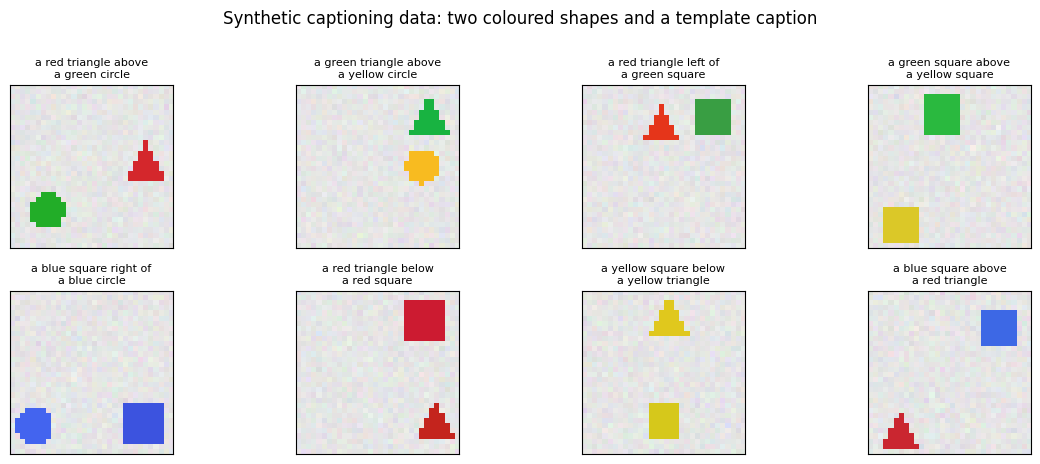

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 4.6))
for k, ax in enumerate(axes.flat):
    show_img(ax, Xtr[k], caps_tr[k].replace(' a ', '\na '))
fig.suptitle('Synthetic captioning data: two coloured shapes and a template caption', y=1.0)
plt.tight_layout(); plt.show()

### Widget 1: browse the dataset

Drag `index` through the training set and read both references. The scene is the same; the sentence changes with the object you start from. That is the only ambiguity a captioner has to live with here, and it is why we keep both references when we score models.

In [5]:
def browse_scene(index=0):
    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    show_img(ax, Xtr[index], f'training scene {index}')
    plt.tight_layout(); plt.show()
    print('target    :', caps_tr[index])
    for r in refs_tr[index]:
        print('reference :', r)
    print('attributes:', {n: int(v) for n, v in zip(list(COLORS) + SHAPES, Atr[index].tolist()) if v})

interact(browse_scene, index=IntSlider(min=0, max=99, step=1, value=0, continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='index', max=99), Output()), _do…

## 1. Show and Tell: a CNN encoder and an RNN decoder

The slide *How to make a computer describe an image?* builds the answer in stages: a CNN turns the image into a vector, a recurrent network turns that vector into words, and the two are trained together on image-sentence pairs. Two papers fixed the recipe: *Vinyals et al., CVPR 2015* (Show and Tell) and *Karpathy and Fei-Fei, CVPR 2015*, whose figures the training and inference slides credit. Both take an ImageNet-pretrained CNN, delete its classifier, and feed the penultimate activation into the language model.

### 1.1 Where the image enters

Karpathy's slide writes the injection as a change to the **first hidden state**. Before, $h_0 = \max(0,\, W_{xh} x_0)$; now $h_0 = \max(0,\, W_{xh} x_0 + W_{ih} v)$, with $v$ the 4096-dimensional VGG-16 activation and $x_0$ the embedding of `<START>`. After that first step the recurrence proceeds as usual, one word at a time, until it emits `<END>`. The cell below checks the two properties the identity promises: with no image ($v = 0$) the modified state collapses to the original one, and the state is a ReLU state, so it is non-negative.

In [6]:
# The image-injection identity, and the property that makes it a ReLU state.
D_img, D_emb, Hh = 4096, 256, 512

W_xh = torch.randn(Hh, D_emb) * 0.02
W_ih = torch.randn(Hh, D_img) * 0.02
x0 = torch.randn(D_emb)                       # the <START> token embedding
v = torch.randn(D_img)                        # the 4096-d image vector

h0_with = torch.relu(W_xh @ x0 + W_ih @ v)
h0_without = torch.relu(W_xh @ x0)

# With no image (v = 0) the modified form collapses to the original.
assert torch.allclose(torch.relu(W_xh @ x0 + W_ih @ torch.zeros(D_img)), h0_without)
assert (h0_with >= 0).all(), 'a ReLU state must be non-negative'
frac_changed = (h0_with != h0_without).float().mean()

print(f'  image vector v: {D_img}-d (VGG-16 with the 1000-way classifier removed)')
print(f'  h0 without image: {h0_without.norm():.3f}   with image: {h0_with.norm():.3f}')
print(f'  {100 * frac_changed:.0f}% of the {Hh} hidden units changed when the image was injected')
print('  setting v = 0 recovers the original recurrence exactly')

  image vector v: 4096-d (VGG-16 with the 1000-way classifier removed)
  h0 without image: 4.340   with image: 19.296
  71% of the 512 hidden units changed when the image was injected
  setting v = 0 recovers the original recurrence exactly


### 1.2 The encoder: a small CNN pretrained on attribute recognition

Karpathy and Vinyals do not train their CNN from scratch on captions: they start from a network that already knows what is in an image, because it was trained on ImageNet. Our stand-in for ImageNet is **attribute recognition**: a three-layer CNN with a linear head that predicts the seven attributes of a scene (which colours and which shapes are present). Trained on 2000 scenes it reaches a high all-seven-correct accuracy in a few seconds.

We then delete the head, exactly as the slides delete VGG's classifier, and keep the network's last convolutional volume: an $8 \times 8$ grid of 48-dimensional **annotation vectors**, $L = 64$ locations of width $D = 48$. Every model in this notebook consumes that grid, so we compute it **once** for all 6400 scenes and cache it. Section 4 will attend over the grid; the models in this section flatten it into a single image vector, the analogue of VGG's fc7.

The attribute predictions themselves are kept too: they are the attribute vectors LSTM-A will inject in Section 6, produced by a detector rather than read off the ground truth.

In [7]:
class Encoder(nn.Module):
    """32x32 image -> (N, L=64, D) grid of annotation vectors: an 8x8 grid of 4x4-pixel cells."""
    def __init__(self, D=48):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.GroupNorm(8, 16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.GroupNorm(8, 32), nn.ReLU(),      # 16 x 16
            nn.Conv2d(32, D, 3, stride=2, padding=1), nn.GroupNorm(8, D), nn.ReLU())        # 8 x 8
    def forward(self, x):
        return self.net(x - 0.5).flatten(2).transpose(1, 2)           # (N, D, 8, 8) -> (N, 64, D)

class AttrNet(nn.Module):
    """Encoder + linear head predicting the 7 attributes: our stand-in for ImageNet pretraining."""
    def __init__(self, D=48, n_attr=7):
        super().__init__()
        self.enc = Encoder(D); self.head = nn.Linear(D * 64, n_attr)
    def forward(self, x):
        return self.head(self.enc(x).flatten(1))

N_PRE, PRE_EPOCHS, bs = 2000, 8, 32
set_seed(0)
attr_net = AttrNet().to(device)
opt = torch.optim.Adam(attr_net.parameters(), lr=3e-3)
t0 = time.time()
for ep in range(PRE_EPOCHS):
    attr_net.train(); perm = torch.randperm(N_PRE, device=device); tot = 0.0
    for i in range(0, N_PRE, bs):
        idx = perm[i:i + bs]
        loss = F.binary_cross_entropy_with_logits(attr_net(Xtr[idx]), Atr[idx])
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(idx)
    attr_net.eval()
    with torch.no_grad():
        pred = (attr_net(Xte) > 0).float()
        per_attr = (pred == Ate).float().mean().item(); all7 = (pred == Ate).all(1).float().mean().item()
    print(f'  epoch {ep + 1}: loss {tot / N_PRE:.3f} | test per-attribute acc {per_attr:.3f} | all 7 correct {all7:.3f}')
print(f'pretrained the encoder on {N_PRE} scenes in {time.time() - t0:.1f} s ({count_params(attr_net):,} parameters)')

# Delete the head, keep the conv grid, cache it for every scene (and keep the predicted attributes).
with torch.no_grad():
    Ftr = torch.cat([attr_net.enc(Xtr[i:i + 500]) for i in range(0, N_TRAIN, 500)])
    Fte = attr_net.enc(Xte)
    Ahat_tr = torch.cat([torch.sigmoid(attr_net(Xtr[i:i + 500])) for i in range(0, N_TRAIN, 500)])
    Ahat_te = torch.sigmoid(attr_net(Xte))
L_GRID, D_ANN = Ftr.shape[1], Ftr.shape[2]
assert L_GRID == 64 and D_ANN == 48
print(f'cached annotation grids: train {tuple(Ftr.shape)}, test {tuple(Fte.shape)} '
      f'({Ftr.numel() * 4 / 1e6:.0f} MB) | L = {L_GRID} locations of width D = {D_ANN}')

  epoch 1: loss 0.473 | test per-attribute acc 0.858 | all 7 correct 0.343


  epoch 2: loss 0.221 | test per-attribute acc 0.913 | all 7 correct 0.530


  epoch 3: loss 0.152 | test per-attribute acc 0.937 | all 7 correct 0.637


  epoch 4: loss 0.096 | test per-attribute acc 0.946 | all 7 correct 0.680


  epoch 5: loss 0.058 | test per-attribute acc 0.965 | all 7 correct 0.777


  epoch 6: loss 0.040 | test per-attribute acc 0.969 | all 7 correct 0.810


  epoch 7: loss 0.021 | test per-attribute acc 0.979 | all 7 correct 0.865


  epoch 8: loss 0.011 | test per-attribute acc 0.983 | all 7 correct 0.890
pretrained the encoder on 2000 scenes in 4.9 s (40,663 parameters)


cached annotation grids: train (6000, 64, 48), test (400, 64, 48) (74 MB) | L = 64 locations of width D = 48


### 1.3 The decoder: a ReLU RNN with the image at the first step, trained with teacher forcing

Now the language model, written to match the slide's equation literally. The **image vector** $v$ is a ReLU projection of the flattened grid (our fc7). The recurrence is

$$h_t = \max\!\big(0,\; W_{xh} x_t + W_{hh} h_{t-1} + b + [t = 1]\, W_{ih} v\big), \qquad p(w_t \mid \cdot) = \mathrm{softmax}(W_{ho} h_t),$$

so the image enters once, at the first step, through the term $W_{ih} v$. The slide indexes the state that receives the image as $h_0$; the paper counts the first word as $t = 1$, which is the convention in the equation above, so $[t = 1]$ and the slide's $h_0$ name the same step. One detail matters enormously in a small model: we initialise $W_{hh}$ to the **identity** (*Le et al., 2015*), so that at initialisation the state, and with it the image, is carried unchanged from step to step. Section 1.4 measures what happens when the recurrence does not preserve the image.

**Teacher forcing** (the training slide) feeds the ground-truth prefix `<start> a red circle ...` as input and asks the network to predict the next word at every position, all positions at once, with a cross-entropy loss that ignores padding. The `forward` below does exactly that; `step` is the same recurrence one token at a time, which is what decoding uses.

Before training we check the from-scratch cell against `nn.RNNCell(nonlinearity='relu')` with the same weights: with $v = 0$ the two must agree exactly, and a whole teacher-forced sequence must agree with `nn.RNN`.

In [8]:
class ShowTellRNN(nn.Module):
    """Karpathy's captioner on a cached annotation grid.
    h_t = relu(W_xh x_t + W_hh h_{t-1} + b + [t == 1] W_ih v); the image enters once."""
    def __init__(self, n_vocab=len(VOCAB), D=D_ANN, L=L_GRID, E=32, H=96, DV=64):
        super().__init__()
        self.fc = nn.Linear(D * L, DV)                   # flattened grid -> image vector v (our fc7)
        self.emb = nn.Embedding(n_vocab, E)
        self.W_xh = nn.Linear(E, H)                      # carries the bias b
        self.W_hh = nn.Linear(H, H, bias=False)
        self.W_ih = nn.Linear(DV, H, bias=False)
        self.out = nn.Linear(H, n_vocab)
        self.H = H
        with torch.no_grad():
            self.W_hh.weight.copy_(torch.eye(H))         # identity recurrence: the state persists at init
    def image_vector(self, f):
        return torch.relu(self.fc(f.flatten(1)))
    def init_state(self, f):
        """State before the first word: h = 0, plus the pending image term W_ih v consumed at t = 1."""
        return (torch.zeros(f.shape[0], self.H, device=f.device), self.W_ih(self.image_vector(f)))
    def _advance(self, tok, state):
        h, pending = state
        h = torch.relu(self.W_xh(self.emb(tok)) + self.W_hh(h) + pending)
        return h, (h, torch.zeros_like(pending))         # after t = 1 the image term is gone
    def step(self, tok, state):
        """One decoding step: log p(next word) and the new state."""
        h, state = self._advance(tok, state)
        return F.log_softmax(self.out(h), -1), state
    def forward(self, f, Y):
        """Teacher forcing: input Y[:, :-1], logits for Y[:, 1:]."""
        state = self.init_state(f); hs = []
        for t in range(Y.shape[1] - 1):
            h, state = self._advance(Y[:, t], state); hs.append(h)
        return self.out(torch.stack(hs, 1))

def caption_loss(logits, Y):
    """Cross-entropy over the shifted targets Y[:, 1:], ignoring padding."""
    return F.cross_entropy(logits.reshape(-1, logits.shape[-1]), Y[:, 1:].reshape(-1), ignore_index=PAD)

# --- check the from-scratch recurrence against PyTorch's ReLU RNN with the same weights ---
set_seed(0)
_m = ShowTellRNN().to(device)
_cell = nn.RNNCell(32, 96, nonlinearity='relu').to(device)
_rnn = nn.RNN(32, 96, nonlinearity='relu', batch_first=True).to(device)
with torch.no_grad():
    for ref_ in (_cell, _rnn):
        w = dict(ref_.named_parameters())
        w['weight_ih' if ref_ is _cell else 'weight_ih_l0'].copy_(_m.W_xh.weight)
        w['bias_ih' if ref_ is _cell else 'bias_ih_l0'].copy_(_m.W_xh.bias)
        w['weight_hh' if ref_ is _cell else 'weight_hh_l0'].copy_(_m.W_hh.weight)
        w['bias_hh' if ref_ is _cell else 'bias_hh_l0'].zero_()
    _tok = Ytr[:8, 1]; _h = torch.rand(8, 96, device=device)
    _ours, _ = _m._advance(_tok, (_h, torch.zeros(8, 96, device=device)))       # v = 0
    _ref = _cell(_m.emb(_tok), _h)
    assert torch.allclose(_ours, _ref, atol=1e-6), 'ReLU RNN step differs from nn.RNNCell'
    _seq, _ = _rnn(_m.emb(Ytr[:8, :-1]))
    _state = (torch.zeros(8, 96, device=device), torch.zeros(8, 96, device=device)); _hs = []
    for t in range(T_MAX - 1):
        _h, _state = _m._advance(Ytr[:8, t], _state); _hs.append(_h)
    assert torch.allclose(torch.stack(_hs, 1), _seq, atol=1e-5), 'sequence differs from nn.RNN'
print(f'from-scratch ReLU RNN == nn.RNNCell / nn.RNN when v = 0   (max diff {(_ours - _ref).abs().max():.1e})')
print(f'ShowTellRNN: {count_params(_m):,} parameters; teacher-forced logits {tuple(_m(Ftr[:4], Ytr[:4]).shape)}')

from-scratch ReLU RNN == nn.RNNCell / nn.RNN when v = 0   (max diff 0.0e+00)
ShowTellRNN: 218,683 parameters; teacher-forced logits (4, 9, 27)


In [9]:
def train_model(model, loss_fn, n, epochs, lr=3e-3, bs=32, label='', print_every=2):
    """Adam on mini-batches of indices; loss_fn(model, idx) -> scalar. Prints at most ~8 lines."""
    set_seed(0); model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist, t0 = [], time.time()
    for ep in range(epochs):
        perm = torch.randperm(n, device=device); tot = 0.0
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            loss = loss_fn(model, idx)
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(idx)
        hist.append(tot / n)
        if print_every and (ep + 1) % print_every == 0:
            print(f'  epoch {ep + 1:2d}: train loss {hist[-1]:.3f}')
    model.eval()
    print(f'{label}: {epochs} epochs in {time.time() - t0:.1f} s, loss {hist[0]:.3f} -> {hist[-1]:.3f}')
    return hist

@torch.no_grad()
def greedy_decode(model, state, T=T_MAX):
    """Feed <start>, take the argmax word, feed it back; after <end> emit <pad>. Returns (N, T) token ids."""
    n = state[0].shape[0]
    tok = torch.full((n,), START, dtype=torch.long, device=device); outs = []
    done = torch.zeros(n, dtype=torch.bool, device=device)
    for t in range(T):
        logp, state = model.step(tok, state)
        tok = torch.where(done, torch.full_like(tok, PAD), logp.argmax(-1)); outs.append(tok)
        done = done | (tok == END)
    return torch.stack(outs, 1)

def captions_of(P):
    return [decode_ids(p.tolist()) for p in P.detach().cpu()]

def exact_match(caps, refs):
    """Fraction of captions that equal one of the references, word for word."""
    return float(np.mean([c in r for c, r in zip(caps, refs)]))

st_loss = lambda m, idx: caption_loss(m(Ftr[idx], Ytr[idx]), Ytr[idx])
set_seed(0)
show_tell = ShowTellRNN().to(device)
hist_st = train_model(show_tell, st_loss, N_TRAIN, epochs=12, bs=32, label='Show and Tell (ReLU RNN)')

caps_st = captions_of(greedy_decode(show_tell, show_tell.init_state(Fte)))
acc_st = exact_match(caps_st, refs_te)
print(f'\ngreedy captions on the {N_TEST} test scenes: exact match {acc_st:.3f}, {len(set(caps_st))} distinct captions')
for k in range(4):
    print(f'  {"OK " if caps_st[k] in refs_te[k] else "BAD"} "{caps_st[k]}"   (reference: "{refs_te[k][0]}")')

  epoch  2: train loss 0.345


  epoch  4: train loss 0.270


  epoch  6: train loss 0.233


  epoch  8: train loss 0.213


  epoch 10: train loss 0.193


  epoch 12: train loss 0.179
Show and Tell (ReLU RNN): 12 epochs in 2.3 s, loss 0.627 -> 0.179

greedy captions on the 400 test scenes: exact match 0.562, 211 distinct captions
  BAD "a red circle right of a yellow square"   (reference: "a red circle left of a yellow square")
  OK  "a green square above a green triangle"   (reference: "a green square above a green triangle")
  OK  "a red triangle above a blue triangle"   (reference: "a red triangle above a blue triangle")
  OK  "a green square above a yellow square"   (reference: "a green square above a yellow square")


### 1.4 A measured claim: the recurrence has to keep the image alive

The slide's recipe injects the image **once**. That is a fragile design in a network trained from scratch, and it is worth seeing the failure rather than reading about it. The cell below trains the same captioner, on the same data and with the same budget (12 epochs, batches of 32), with the other common choice, an LSTM whose initial state is a $\tanh$ projection of the image ($h_0 = \tanh(W_h v)$, $c_0 = \tanh(W_c v)$), and records the gradient that reaches the image projection `fc` during the first 150 updates of both models.

What to expect: the LSTM quickly finds the **unconditional language model** (the captions are so regular that "a red circle above a blue square" is a good guess for every image), its gates learn to forget the initial state, the gradient into `fc` collapses by several orders of magnitude, and from then on the image recovers only slowly: with the budget that took the ReLU RNN to 56% exact match, the LSTM reaches about 17%. The identity-initialised ReLU RNN never lets go of the image, so the gradient stays alive and the model keeps improving. Every trick later in the lecture, feeding the image at every step (LSTM-A4, A5) or attending to it at every step (Section 4), is a way of not depending on this fragile path.

In [10]:
class ShowTellLSTM(nn.Module):
    """The same captioner with an LSTM whose initial state is a tanh projection of the image."""
    def __init__(self, n_vocab=len(VOCAB), D=D_ANN, L=L_GRID, E=32, H=96, DV=64):
        super().__init__()
        self.fc = nn.Linear(D * L, DV); self.emb = nn.Embedding(n_vocab, E)
        self.init_h = nn.Linear(DV, H); self.init_c = nn.Linear(DV, H)
        self.cell = nn.LSTMCell(E, H); self.out = nn.Linear(H, n_vocab)
    def init_state(self, f):
        v = torch.relu(self.fc(f.flatten(1)))
        return (torch.tanh(self.init_h(v)), torch.tanh(self.init_c(v)))
    def step(self, tok, state):
        h, c = self.cell(self.emb(tok), state)
        return F.log_softmax(self.out(h), -1), (h, c)
    def forward(self, f, Y):
        state = self.init_state(f); hs = []
        for t in range(Y.shape[1] - 1):
            h, c = self.cell(self.emb(Y[:, t]), state); state = (h, c); hs.append(h)
        return self.out(torch.stack(hs, 1))

def grad_trace(model, steps=150, bs=32, at=(0, 25, 50, 100, 149)):
    """Gradient norm reaching the image projection fc during the first updates."""
    set_seed(0); model.train(); opt = torch.optim.Adam(model.parameters(), lr=3e-3); trace = {}
    for s in range(steps):
        idx = torch.randint(0, N_TRAIN, (bs,), device=device)
        loss = st_loss(model, idx); opt.zero_grad(); loss.backward()
        if s in at:
            trace[s] = model.fc.weight.grad.norm().item()
        opt.step()
    model.eval(); return trace

set_seed(0); tr_rnn = grad_trace(ShowTellRNN().to(device))
set_seed(0); tr_lstm = grad_trace(ShowTellLSTM().to(device))
print('gradient norm reaching fc (the image path):')
print('  step        ' + ''.join(f'{s:>10d}' for s in tr_rnn))
print('  ReLU RNN    ' + ''.join(f'{v:>10.1e}' for v in tr_rnn.values()))
print('  LSTM h0,c0  ' + ''.join(f'{v:>10.1e}' for v in tr_lstm.values()))
decay_rnn, decay_lstm = tr_rnn[149] / tr_rnn[0], tr_lstm[149] / tr_lstm[0]
print(f'  after 150 updates the image-path gradient is x{decay_rnn:.2f} (ReLU RNN) and x{decay_lstm:.1e} (LSTM) of its initial size')
assert decay_lstm < 0.1 * decay_rnn, 'expected the LSTM image path to decay far more than the ReLU RNN one'

set_seed(0)
st_lstm = ShowTellLSTM().to(device)
train_model(st_lstm, st_loss, N_TRAIN, epochs=12, bs=32, label='Show and Tell (LSTM, image in h0/c0)', print_every=0)   # same budget as 1.3
caps_lstm = captions_of(greedy_decode(st_lstm, st_lstm.init_state(Fte)))
print(f'  exact match {exact_match(caps_lstm, refs_te):.3f}, {len(set(caps_lstm))} distinct caption(s) on {N_TEST} test scenes: '
      f'"{Counter(caps_lstm).most_common(1)[0][0]}"')
print(f'  ReLU RNN from 1.3 for comparison: exact match {acc_st:.3f}, {len(set(caps_st))} distinct captions')

gradient norm reaching fc (the image path):
  step                 0        25        50       100       149
  ReLU RNN       7.4e-01   3.2e-01   3.9e-01   3.6e-01   3.3e-01
  LSTM h0,c0     1.4e-01   2.4e-05   8.7e-07   3.3e-07   2.7e-07
  after 150 updates the image-path gradient is x0.45 (ReLU RNN) and x1.9e-06 (LSTM) of its initial size


Show and Tell (LSTM, image in h0/c0): 12 epochs in 4.7 s, loss 0.957 -> 0.386
  exact match 0.168, 65 distinct caption(s) on 400 test scenes: "a green triangle above a red square"
  ReLU RNN from 1.3 for comparison: exact match 0.562, 211 distinct captions


## 2. Inference: greedy decoding, beam search and sampling

The inference slide (Karpathy's figure) runs the trained network forward one word at a time: feed `<START>`, read a distribution over the vocabulary, pick a word, feed it back as the next input, stop at `<END>`. **Greedy** decoding picks the argmax at every step, which is what `greedy_decode` above does. It is fast but it commits: a slightly wrong first word cannot be undone by anything that follows.

**Beam search** keeps the $k$ most probable partial captions instead of one. At every step each of the $k$ beams is extended by every word, the $k \times |V|$ candidates are scored by their total log-probability, and the best $k$ survive. With $k = 1$ it is greedy decoding; with $k$ larger than the number of possible sequences it is exhaustive search, which is the property we use to test it.

The implementation below is **batched**: all $N$ images and all $k$ beams run in one tensor of shape $(N k, \cdot)$, and the recurrent state is re-indexed after every step so that each surviving beam inherits the state of the beam it came from. Beams that have emitted `<END>` are frozen by allowing them only a zero-cost `<pad>` continuation.

In [11]:
def reorder(state, idx):
    """Re-index every tensor of a recurrent state along the batch dimension."""
    return tuple(s[idx] for s in state)

@torch.no_grad()
def beam_search(model, state, k=3, T=T_MAX):
    """Batched beam search. Returns token ids (N, k, T) and total log-probs (N, k), best beam first."""
    n = state[0].shape[0]
    logp, state = model.step(torch.full((n,), START, dtype=torch.long, device=device), state)
    n_vocab = logp.shape[-1]
    pad_only = torch.full((n_vocab,), -1e9, device=device); pad_only[PAD] = 0.0   # finished beams pay nothing
    scores, tok = logp.topk(min(k, n_vocab), -1)                  # (N, k): the first k words
    seqs = tok.unsqueeze(-1)                                      # (N, k, 1)
    k_cur = scores.shape[1]                                       # fewer than k beams while fewer candidates exist
    state = reorder(state, torch.arange(n, device=device).repeat_interleave(k_cur))   # every beam gets a copy
    done = tok == END
    for t in range(1, T):
        logp, state = model.step(tok.reshape(-1), state)          # (N k, V)
        logp = torch.where(done.reshape(-1, 1), pad_only, logp).reshape(n, k_cur, n_vocab)
        cand = (scores.unsqueeze(-1) + logp).reshape(n, k_cur * n_vocab)
        scores, flat = cand.topk(min(k, cand.shape[-1]), -1)      # best k of the k x V candidates
        beam = torch.div(flat, n_vocab, rounding_mode='floor'); tok = flat % n_vocab
        seqs = torch.cat([seqs.gather(1, beam.unsqueeze(-1).expand(-1, -1, seqs.shape[-1])), tok.unsqueeze(-1)], -1)
        state = reorder(state, (torch.arange(n, device=device).unsqueeze(1) * k_cur + beam).reshape(-1))
        done = done.gather(1, beam) | (tok == END)
        k_cur = scores.shape[1]
    return seqs, scores

# --- check 1: k = 1 is greedy decoding, on every test scene ---
g = greedy_decode(show_tell, show_tell.init_state(Fte))
b1, _ = beam_search(show_tell, show_tell.init_state(Fte), k=1)
assert torch.equal(g, b1[:, 0]), 'beam search with k = 1 must equal greedy decoding'

# --- check 2: on a toy Markov model, a wide enough beam equals exhaustive search ---
class ToyMarkov:
    """A random 3-step model over tokens {3, 4, 5}; p(next | previous, step) is a fixed table."""
    def __init__(self, T=3, n_vocab=6, seed=0):
        gen = torch.Generator().manual_seed(seed)
        table = torch.randn(T, n_vocab, n_vocab, generator=gen) * 2
        table[:, :, :3] = -1e9                                    # never emit <pad>, <start>, <end>
        self.table = F.log_softmax(table, -1).to(device); self.T = T
    def init_state(self, n):
        return (torch.zeros(n, dtype=torch.long, device=device),)  # the step counter, per beam
    def step(self, tok, state):
        t = state[0]
        return self.table[t.clamp(max=self.T - 1), tok], (t + 1,)

toy = ToyMarkov()
seqs_all = list(itertools.product([3, 4, 5], repeat=3))          # all 27 sequences
def toy_score(seq):
    s, prev = 0.0, START
    for t, w in enumerate(seq):
        s += toy.table[t, prev, w].item(); prev = w
    return s
best = max(seqs_all, key=toy_score)
bw, sc = beam_search(toy, toy.init_state(1), k=27, T=3)
assert tuple(bw[0, 0].tolist()) == best and abs(sc[0, 0].item() - toy_score(best)) < 1e-4, 'beam k=27 is not exhaustive'
sc_k = [beam_search(toy, toy.init_state(1), k=k_, T=3)[1][0, 0].item() for k_ in (1, 2, 3, 27)]
assert all(a <= b + 1e-6 for a, b in zip(sc_k, sc_k[1:])), 'a wider beam must never score lower'
print('beam search: k = 1 equals greedy on all test scenes; k = 27 equals exhaustive search on the toy model')
print('  toy model, best total log-prob by beam width 1 / 2 / 3 / 27:', ' / '.join(f'{s:.3f}' for s in sc_k),
      f'(exhaustive {toy_score(best):.3f})')

beam search: k = 1 equals greedy on all test scenes; k = 27 equals exhaustive search on the toy model
  toy model, best total log-prob by beam width 1 / 2 / 3 / 27: -0.789 / -0.789 / -0.789 / -0.789 (exhaustive -0.789)


Does a wider beam help the real captioner? Beam search maximises log-probability, not correctness, so the two curves below can disagree. The right panel shows the mean total log-probability of the best beam rising monotonically with $k$; the left panel shows exact match, which is what we care about.

  beam width 1: exact match 0.562 | mean log-prob of the best caption -0.946
  beam width 2: exact match 0.570 | mean log-prob of the best caption -0.934
  beam width 3: exact match 0.568 | mean log-prob of the best caption -0.932
  beam width 5: exact match 0.568 | mean log-prob of the best caption -0.932
  beam width 8: exact match 0.568 | mean log-prob of the best caption -0.932


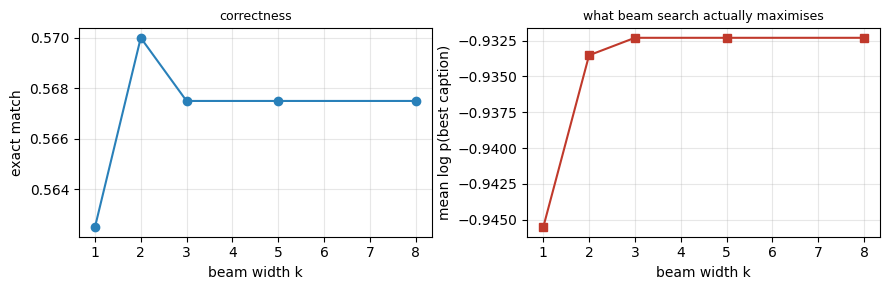

In [12]:
BEAMS = [1, 2, 3, 5, 8]
beam_results = {}
for k_ in BEAMS:
    seqs, scores = beam_search(show_tell, show_tell.init_state(Fte), k=k_)
    caps_k = captions_of(seqs[:, 0])
    beam_results[k_] = dict(caps=caps_k, exact=exact_match(caps_k, refs_te), logp=scores[:, 0].mean().item(),
                            seqs=seqs.cpu(), scores=scores.cpu())
    print(f'  beam width {k_}: exact match {beam_results[k_]["exact"]:.3f} | mean log-prob of the best caption {beam_results[k_]["logp"]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(BEAMS, [beam_results[k_]['exact'] for k_ in BEAMS], 'o-', color='#2980b9')
axes[0].set_xlabel('beam width k'); axes[0].set_ylabel('exact match'); axes[0].grid(alpha=0.3); axes[0].set_title('correctness', fontsize=9)
axes[1].plot(BEAMS, [beam_results[k_]['logp'] for k_ in BEAMS], 's-', color='#c0392b')
axes[1].set_xlabel('beam width k'); axes[1].set_ylabel('mean log p(best caption)'); axes[1].grid(alpha=0.3)
axes[1].set_title('what beam search actually maximises', fontsize=9)
plt.tight_layout(); plt.show()

### Widget 2: the beams of one scene

Pick a test scene and a beam width. The list shows the surviving beams with their total log-probability; the top one is the model's answer. Compare `k = 1` with `k = 5` on scenes where greedy decoding is wrong (the caption is marked BAD) and watch whether a better-scoring sentence was hiding one step behind the greedy choice.

In [13]:
def show_beams(index=0, k=3):
    seqs, scores = beam_results[k]['seqs'], beam_results[k]['scores']
    fig, ax = plt.subplots(figsize=(3.0, 3.0))
    show_img(ax, Xte[index], f'test scene {index}')
    plt.tight_layout(); plt.show()
    print('references:', ' | '.join(refs_te[index]))
    for j in range(k):
        cap = decode_ids(seqs[index, j].tolist())
        mark = 'OK ' if cap in refs_te[index] else 'BAD'
        print(f'  beam {j + 1}: log p = {scores[index, j]:7.3f}  {mark} "{cap}"')

interact(show_beams, index=IntSlider(min=0, max=N_TEST - 1, step=1, value=0, continuous_update=False),
         k=Dropdown(options=BEAMS, value=3, description='beam k'));

interactive(children=(IntSlider(value=0, continuous_update=False, description='index', max=399), Dropdown(desc…

### Sampling with a temperature

Argmax and beam search both return the mode. A third option is to **sample** the next word from $\mathrm{softmax}(\text{logits} / \tau)$. The temperature $\tau$ interpolates between greedy decoding ($\tau \to 0$) and the model's own distribution ($\tau = 1$); above 1 the distribution flattens and the captions turn into noise. We sample 12 captions for six test scenes at five temperatures and count how many distinct sentences appear and how many are correct.

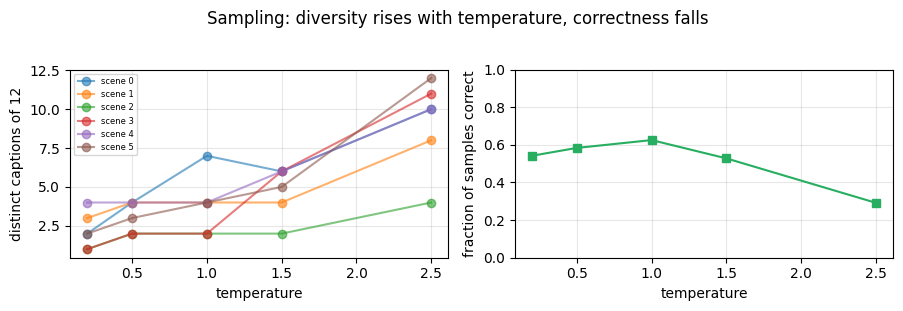

mean distinct captions per scene at tau = 0.2: 2.2, 0.5: 3.2, 1.0: 3.8, 1.5: 4.8, 2.5: 9.2


In [14]:
@torch.no_grad()
def sample_captions(model, f, tau=1.0, n_samples=12, T=T_MAX, seed=0):
    """Draw n_samples captions for one scene by sampling from softmax(logits / tau) at every step."""
    set_seed(seed)
    state = model.init_state(f.expand(n_samples, -1, -1))
    tok = torch.full((n_samples,), START, dtype=torch.long, device=device); outs = []
    for t in range(T):
        logp, state = model.step(tok, state)
        tok = torch.multinomial(torch.softmax(logp / tau, -1), 1).squeeze(1); outs.append(tok)
    return captions_of(torch.stack(outs, 1))

TAUS = [0.2, 0.5, 1.0, 1.5, 2.5]
SAMPLE_SCENES = [0, 1, 2, 3, 4, 5]
samples = {(i, tau): sample_captions(show_tell, Fte[i:i + 1], tau) for i in SAMPLE_SCENES for tau in TAUS}
distinct = np.array([[len(set(samples[(i, tau)])) for tau in TAUS] for i in SAMPLE_SCENES])
correct = np.array([[np.mean([c in refs_te[i] for c in samples[(i, tau)]]) for tau in TAUS] for i in SAMPLE_SCENES])

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for i, row in zip(SAMPLE_SCENES, distinct):
    axes[0].plot(TAUS, row, 'o-', alpha=0.6, label=f'scene {i}')
axes[0].set_xlabel('temperature'); axes[0].set_ylabel('distinct captions of 12'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=6)
axes[1].plot(TAUS, correct.mean(0), 's-', color='#27ae60')
axes[1].set_xlabel('temperature'); axes[1].set_ylabel('fraction of samples correct'); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1)
fig.suptitle('Sampling: diversity rises with temperature, correctness falls', y=1.02)
plt.tight_layout(); plt.show()
print('mean distinct captions per scene at tau =', ', '.join(f'{t}: {d:.1f}' for t, d in zip(TAUS, distinct.mean(0))))

### Widget 3: temperature

Choose a scene and a temperature and read the 12 sampled captions, grouped with their counts. At $\tau = 0.2$ almost every sample is the greedy caption; around $\tau = 1$ the second reference (the same scene read from the other object) starts to appear; at $\tau = 2.5$ the grammar itself breaks.

In [15]:
def show_samples(index=0, tau=1.0):
    fig, ax = plt.subplots(figsize=(3.0, 3.0))
    show_img(ax, Xte[index], f'test scene {index}')
    plt.tight_layout(); plt.show()
    print('references:', ' | '.join(refs_te[index]))
    for cap, cnt in Counter(samples[(index, tau)]).most_common():
        print(f'  x{cnt:2d}  {"OK " if cap in refs_te[index] else "BAD"} "{cap}"')

interact(show_samples, index=Dropdown(options=SAMPLE_SCENES, value=0, description='scene'),
         tau=Dropdown(options=TAUS, value=1.0, description='tau'));

interactive(children=(Dropdown(description='scene', options=(0, 1, 2, 3, 4, 5), value=0), Dropdown(description…

## 3. Evaluating captions: BLEU, and the failure cases

The results slides report **BLEU** scores. BLEU (*Papineni et al., ACL 2002*) compares a candidate caption with a set of references by counting matching $n$-grams, with two corrections that make it hard to cheat:

- **Modified $n$-gram precision** $p_n$: the count of each candidate $n$-gram is *clipped* at the maximum number of times it occurs in any single reference, then divided by the total number of candidate $n$-grams. Without clipping, "the the the the the the the" would score $7/7$ on unigrams against "the cat is on the mat"; with clipping it scores $2/7$, because "the" occurs at most twice in a reference. The precisions are accumulated over the whole corpus, not averaged per sentence.
- **Brevity penalty** $BP = \min(1, e^{1 - r/c})$, where $c$ is the total candidate length and $r$ the total length of the closest references. Precision alone rewards short captions; the penalty punishes them.

$$\text{BLEU-}N = BP \cdot \exp\Big(\frac{1}{N} \sum_{n=1}^{N} \log p_n\Big)$$

BLEU-1 rewards the right words, BLEU-4 rewards the right words in the right order. We implement it from scratch and check it against the values the paper works out by hand.

In [16]:
def ngrams(words, n):
    return Counter(tuple(words[i:i + n]) for i in range(len(words) - n + 1))

def clipped_counts(hyp, refs, n):
    """(clipped matches, total candidate n-grams) for one candidate against its references."""
    cand = ngrams(hyp, n)
    max_ref = Counter()
    for r in refs:
        for g, c in ngrams(r, n).items():
            max_ref[g] = max(max_ref[g], c)
    clipped = sum(min(c, max_ref[g]) for g, c in cand.items())
    return clipped, sum(cand.values())

def bleu(hyps, refs_list, max_n=4):
    """Corpus BLEU-1 .. BLEU-max_n. hyps: list of strings; refs_list: list of lists of strings."""
    hyps = [h.split() for h in hyps]; refs_list = [[r.split() for r in rs] for rs in refs_list]
    match = np.zeros(max_n); total = np.zeros(max_n); c_len = r_len = 0
    for h, rs in zip(hyps, refs_list):
        for n in range(1, max_n + 1):
            m, t = clipped_counts(h, rs, n); match[n - 1] += m; total[n - 1] += t
        c_len += len(h)
        r_len += min((abs(len(r) - len(h)), len(r)) for r in rs)[1]        # closest reference length
    p = match / np.maximum(total, 1)
    bp = 1.0 if c_len > r_len else math.exp(1 - r_len / max(c_len, 1))
    out = []
    for N in range(1, max_n + 1):
        out.append(0.0 if (p[:N] == 0).any() else bp * math.exp(np.log(p[:N]).mean()))
    return out

# --- hand-checked values ---
refs_cat = [['the cat is on the mat', 'there is a cat on the mat']]
assert clipped_counts('the the the the the the the'.split(), [r.split() for r in refs_cat[0]], 1) == (2, 7)   # Papineni's example
assert np.allclose(bleu(['the cat is on the mat'], refs_cat), [1, 1, 1, 1])                                 # identical caption
b_short = bleu(['the cat is on the mat'], [['the cat is on the mat and it is asleep']])
assert abs(b_short[1] - math.exp(1 - 10 / 6)) < 1e-9, 'brevity penalty: c = 6 words against r = 10'
assert bleu(['a red circle above a blue square'], [['a blue square below a red circle']])[3] == 0.0           # no matching 4-gram
print("Papineni's example: clipped unigram precision of 'the the the ... the' = 2/7           ok")
print('identical caption -> BLEU-1..4 = 1                                                 ok')
print(f'6-word candidate vs 10-word reference -> BP = exp(1 - 10/6) = {math.exp(1 - 10 / 6):.4f}             ok')
print('same scene read from the other object -> BLEU-1 %.3f but BLEU-4 %.3f' % (bleu(['a red circle above a blue square'], [['a blue square below a red circle']])[0],
      bleu(['a red circle above a blue square'], [['a blue square below a red circle']])[3]))

Papineni's example: clipped unigram precision of 'the the the ... the' = 2/7           ok
identical caption -> BLEU-1..4 = 1                                                 ok
6-word candidate vs 10-word reference -> BP = exp(1 - 10/6) = 0.5134             ok
same scene read from the other object -> BLEU-1 0.857 but BLEU-4 0.000


### 3.1 Results

With a trusted metric we can score what Sections 1 and 2 produced. The last row is a **constant caption**, the most frequent training target emitted for every image: it is the baseline any captioner has to beat, and it shows why BLEU-1 on its own says very little (most of its words are in every reference).

In [17]:
const_cap = Counter(caps_tr).most_common(1)[0][0]
rows = [('Show and Tell, greedy', caps_st), ('Show and Tell, beam k = 3', beam_results[3]['caps']),
        ('Show and Tell, beam k = 8', beam_results[8]['caps']), ('LSTM with image in h0/c0 (1.4)', caps_lstm),
        (f'constant caption "{const_cap}"', [const_cap] * N_TEST)]
print(f'{"model":42s} {"BLEU-1":>7s} {"BLEU-2":>7s} {"BLEU-3":>7s} {"BLEU-4":>7s} {"exact":>7s}')
results_table = {}
for name, caps in rows:
    b = bleu(caps, refs_te); results_table[name] = b + [exact_match(caps, refs_te)]
    print(f'{name:42s} ' + ' '.join(f'{v:7.3f}' for v in results_table[name]))
bleu_st = results_table['Show and Tell, greedy']

model                                       BLEU-1  BLEU-2  BLEU-3  BLEU-4   exact
Show and Tell, greedy                        0.992   0.924   0.864   0.795   0.562
Show and Tell, beam k = 3                    0.993   0.921   0.858   0.790   0.568
Show and Tell, beam k = 8                    0.993   0.921   0.858   0.790   0.568
LSTM with image in h0/c0 (1.4)               0.852   0.768   0.636   0.493   0.168
constant caption "a green circle above a green square"   0.609   0.427   0.310   0.207   0.003


### 3.2 Failure cases

The lecture shows two kinds of failures. In the first (*"possible to understand why the method failed"*) the wrong word points at something plausible in the picture; in the second (*"not possible to understand why the method failed"*) the caption is simply wrong and the model gives no clue about what it looked at. Our captions have a fixed grammar, so every wrong caption can be **classified** automatically:

- **wrong relation**: both objects are right, the spatial word is not;
- **wrong colour** or **wrong shape**: one object is described with the right shape but the wrong colour, or vice versa;
- **hallucinated object**: an object that is not in the scene at all;
- **same object twice**: the caption relates an object to itself;
- **ungrammatical**: the sentence does not parse.

We count them on the greedy captions and look at six failures. The question the slide asks next, *"How can we mitigate these failures?"*, is what attention answers: right now there is no way to tell which part of the image produced the wrong word.

greedy captions on the test set:
  correct               225  (56.2%)
  wrong colour           97  (24.2%)
  wrong relation         63  (15.8%)
  wrong shape            14  (3.5%)
  same object twice       1  (0.2%)


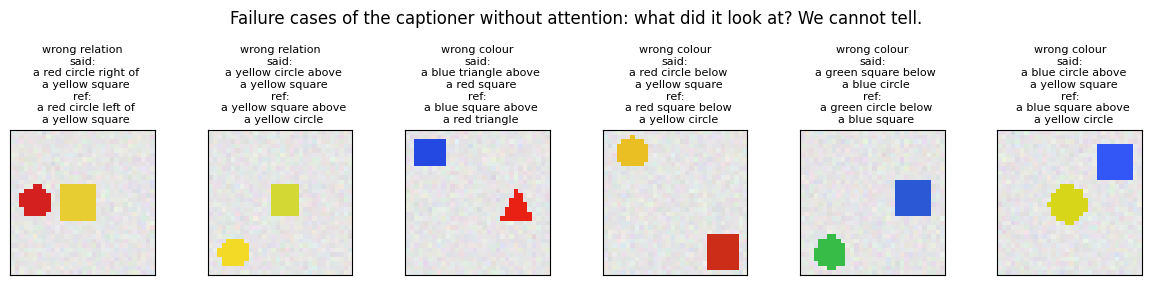

In [18]:
def parse_caption(cap):
    """'a c1 s1 rel a c2 s2' -> dict, or None if the sentence does not follow the grammar."""
    w = cap.split()
    if len(w) < 7 or w[0] != 'a' or w[1] not in COLORS or w[2] not in SHAPES:
        return None
    k = 5 if w[3] in ('left', 'right') else 4
    rel = ' '.join(w[3:k])
    if rel not in ('above', 'below', 'left of', 'right of') or len(w) != k + 3:
        return None
    if w[k] != 'a' or w[k + 1] not in COLORS or w[k + 2] not in SHAPES:
        return None
    return dict(subj=(w[1], w[2]), rel=rel, obj=(w[k + 1], w[k + 2]))

def classify_failure(cap, objs, refs):
    if cap in refs:
        return 'correct'
    p = parse_caption(cap)
    if p is None:
        return 'ungrammatical'
    if p['subj'] == p['obj']:
        return 'same object twice'
    present = [(o['color'], o['shape']) for o in objs]
    for key in ('subj', 'obj'):
        c, s = p[key]
        if (c, s) not in present:
            if any(s == s_ for _, s_ in present):
                return 'wrong colour'
            if any(c == c_ for c_, _ in present):
                return 'wrong shape'
            return 'hallucinated object'
    return 'wrong relation'

fail_st = [classify_failure(c, o, r) for c, o, r in zip(caps_st, objs_te, refs_te)]
print('greedy captions on the test set:')
for kind, cnt in Counter(fail_st).most_common():
    print(f'  {kind:20s} {cnt:4d}  ({100 * cnt / N_TEST:.1f}%)')
fail_idx = [i for i, k in enumerate(fail_st) if k != 'correct']

fig, axes = plt.subplots(1, 6, figsize=(12, 2.6))
for ax, i in zip(axes, fail_idx[:6]):
    show_img(ax, Xte[i], f'{fail_st[i]}\nsaid: {caps_st[i]}\nref: {refs_te[i][0]}'.replace(' a ', '\n  a '))
fig.suptitle('Failure cases of the captioner without attention: what did it look at? We cannot tell.', y=1.08)
plt.tight_layout(); plt.show()

## 4. Show, Attend and Tell: soft attention over the feature grid

*Xu et al., ICML 2015* keep the spatial grid instead of collapsing it. The CNN produces $L$ annotation vectors of width $D$, where $L = W \times H$ is the number of spatial locations (the slide's VGG example gives $14 \times 14 = 196$ vectors of width 512; our encoder gives $8 \times 8 = 64$ vectors of width 48). At every step the decoder emits a **distribution over the $L$ locations**, and the context it consumes is their weighted combination:

$$z_t = \sum_{i=1}^{L} \alpha_{t,i}\, v_i, \qquad \sum_i \alpha_{t,i} = 1.$$

The decoder state then feeds two heads: the next attention distribution, and the distribution over the vocabulary. The cell below is the shape check from the slides with their numbers.

*A notation warning.* The slides write $a_t$ for the attention weights, $z_t$ for the weighted features and $d_t$ for the vocabulary distribution; the annotation vectors are only labelled "features, $L \times D$" there, and we call them $v_i$. The paper uses the opposite letters: $a_i$ are the annotations there, $\alpha_{t,i}$ the weights and $\hat z_t$ the context. Read carefully when moving between the two.

In [19]:
# The captioning attention step, with the shapes the slides give.
W_grid, H_grid, D_ann = 14, 14, 512
L = W_grid * H_grid                            # "Features: L x D, where L = W x H"
assert L == 196

V_ann = torch.randn(L, D_ann)                  # the annotation vectors v_1 ... v_L
h_dec = torch.randn(D_ann)

a = torch.softmax(V_ann @ h_dec, dim=0)        # "Distribution over L locations"
z = (a[:, None] * V_ann).sum(0)                # z_t = sum_i a_i v_i

assert a.shape == (L,) and z.shape == (D_ann,)
assert torch.allclose(a.sum(), torch.tensor(1.0), atol=1e-6)
assert torch.allclose(z, a @ V_ann, atol=1e-5)

vocab = 10000
d_vocab = torch.softmax(torch.randn(vocab), dim=0)
assert torch.allclose(d_vocab.sum(), torch.tensor(1.0), atol=1e-5)

print(f'  14 x 14 feature map -> L = {L} annotation vectors of width D = {D_ann}')
print(f'  attention a: {tuple(a.shape)}, sums to {a.sum():.4f}   ("distribution over L locations")')
print(f'  context  z: {tuple(z.shape)}                        ("weighted features: D")')
print(f'  vocab head: {tuple(d_vocab.shape)}, sums to {d_vocab.sum():.4f}  ("distribution over vocab")')

  14 x 14 feature map -> L = 196 annotation vectors of width D = 512
  attention a: (196,), sums to 1.0000   ("distribution over L locations")
  context  z: (512,)                        ("weighted features: D")
  vocab head: (10000,), sums to 1.0000  ("distribution over vocab")


### 4.1 The attention step, verified

One step of attention is three lines: a score for every location from the decoder state (we use a scaled dot product between a query $q = W_q h$ and keys $k_i = W_k v_i$), a softmax over the $L$ scores, and the weighted sum of the annotations. `F.scaled_dot_product_attention` computes exactly this for a single query, so we can check the from-scratch version against it.

In [20]:
def attend_scratch(q, keys, values):
    """One attention step. q: (N, d), keys: (N, L, d), values: (N, L, D) -> context (N, D), weights (N, L)."""
    e = (keys @ q.unsqueeze(-1)).squeeze(-1) / math.sqrt(q.shape[-1])     # score per location
    alpha = torch.softmax(e, -1)                                            # distribution over L locations
    return (alpha.unsqueeze(-1) * values).sum(1), alpha                     # z = sum_i alpha_i v_i

set_seed(0)
# (keys and values of the same width here, which every backend's SDPA kernel supports)
_q = torch.randn(5, 32, device=device); _k = torch.randn(5, L_GRID, 32, device=device); _v = torch.randn(5, L_GRID, 32, device=device)
_z, _alpha = attend_scratch(_q, _k, _v)
_z_ref = F.scaled_dot_product_attention(_q.unsqueeze(1), _k, _v).squeeze(1)
assert torch.allclose(_z, _z_ref, atol=1e-5), 'attention step differs from F.scaled_dot_product_attention'
assert torch.allclose(_alpha.sum(-1), torch.ones(5, device=device), atol=1e-6)
print(f'attend_scratch == F.scaled_dot_product_attention   (max diff {(_z - _z_ref).abs().max():.1e}); weights sum to 1')

attend_scratch == F.scaled_dot_product_attention   (max diff 1.8e-07); weights sum to 1


### 4.2 The soft-attention decoder

The decoder is an LSTM cell whose input at step $t$ is the previous word's embedding concatenated with the context $z_t$; the attention query is the previous hidden state $h_{t-1}$, so the model decides where to look before it decides what to say. The initial state is a projection of the **mean annotation**, as in the paper. Because $z_t$ is a differentiable function of $\alpha_t$, the whole model trains by ordinary backpropagation on the same teacher-forcing loss as before.

One addition to the paper's recipe is needed at our scale. Xu et al.'s annotation vectors come from VGG's last convolutional layer, whose receptive fields cover most of the image, so each vector implicitly knows where it is. Our three-layer encoder sees a 4-pixel cell and a little context: its vectors say *what* is there, not *where*, and a weighted average of them throws the position away entirely. We therefore append each cell's normalised (row, column) to its annotation vector, the trick of CoordConv (*Liu et al., NeurIPS 2018*), giving $D = 50$. Section 4.5 measures what happens without it.

The same class runs in `hard` mode in Section 5: there the context is a single sampled annotation and the step also returns the log-probability of the location it picked, which the REINFORCE estimator needs.

In [21]:
class AttnCaptioner(nn.Module):
    """Show, Attend and Tell decoder on a cached annotation grid. mode = 'soft' or 'hard'."""
    def __init__(self, mode='soft', n_vocab=len(VOCAB), D=D_ANN, E=32, H=96, K=32):
        super().__init__()
        self.mode = mode; self.emb = nn.Embedding(n_vocab, E)
        self.init_h = nn.Linear(D, H); self.init_c = nn.Linear(D, H)
        self.Wk = nn.Linear(D, K); self.Wq = nn.Linear(H, K)
        self.cell = nn.LSTMCell(E + D, H); self.out = nn.Linear(H, n_vocab)
    def init_state(self, ann):
        v = ann.mean(1)                                                     # mean annotation starts the LSTM
        return (torch.tanh(self.init_h(v)), torch.tanh(self.init_c(v)), ann, self.Wk(ann))
    def attend(self, h, ann, keys, sample=False):
        """Soft: expected context. Hard: one location (sampled while training, argmax at test time)."""
        _, alpha = attend_scratch(self.Wq(h), keys, ann)
        if self.mode == 'soft':
            return (alpha.unsqueeze(-1) * ann).sum(1), alpha, None
        pick = torch.multinomial(alpha, 1).squeeze(-1) if sample else alpha.argmax(-1)
        ar = torch.arange(ann.shape[0], device=ann.device)
        return ann[ar, pick], alpha, torch.log(alpha[ar, pick] + 1e-9)
    def forward(self, ann, Y, sample=False, mix=0.0):
        """Teacher forcing. Returns logits (N, T-1, V), attention maps (N, T-1, L), log p(location) or None."""
        h, c, ann, keys = self.init_state(ann); logits, alphas, logps = [], [], []
        for t in range(Y.shape[1] - 1):
            z, alpha, logp = self.attend(h, ann, keys, sample)
            if sample and mix > 0 and torch.rand(()) < mix:                 # Xu et al.: expected context half the time
                z = (alpha.unsqueeze(-1) * ann).sum(1)
            h, c = self.cell(torch.cat([self.emb(Y[:, t]), z], -1), (h, c))
            logits.append(self.out(h)); alphas.append(alpha); logps.append(logp)
        return torch.stack(logits, 1), torch.stack(alphas, 1), (torch.stack(logps, 1) if logps[0] is not None else None)
    @torch.no_grad()
    def decode(self, ann, T=T_MAX):
        """Greedy decoding that also returns the attention map used for every word."""
        h, c, ann, keys = self.init_state(ann)
        tok = torch.full((ann.shape[0],), START, dtype=torch.long, device=device); outs, maps = [], []
        for t in range(T):
            z, alpha, _ = self.attend(h, ann, keys, sample=False)
            h, c = self.cell(torch.cat([self.emb(tok), z], -1), (h, c))
            tok = self.out(h).argmax(-1); outs.append(tok); maps.append(alpha)
        return torch.stack(outs, 1), torch.stack(maps, 1)

# Coordinate channels: a 4-pixel cell's features say what is there, not where. Append (row, col) in [-1, 1].
_r, _c = torch.meshgrid(torch.arange(8), torch.arange(8), indexing='ij')
POS = ((torch.stack([_r.flatten(), _c.flatten()], -1).float() + 0.5) / 8 * 2 - 1).to(device)     # (64, 2)
def with_coords(f):
    """(N, L, D) annotations -> (N, L, D + 2) with each cell's normalised (row, col) appended."""
    return torch.cat([f, POS.unsqueeze(0).expand(f.shape[0], -1, -1)], -1)
Ftr_pos, Fte_pos = with_coords(Ftr), with_coords(Fte)
D_POS = Ftr_pos.shape[-1]

soft_loss = lambda m, idx: caption_loss(m(Ftr_pos[idx], Ytr[idx])[0], Ytr[idx])
set_seed(0)
soft = AttnCaptioner('soft', D=D_POS).to(device)
hist_soft = train_model(soft, soft_loss, N_TRAIN, epochs=12, bs=64, label='soft attention', print_every=3)
P_soft, M_soft = soft.decode(Fte_pos)
caps_soft = captions_of(P_soft); bleu_soft = bleu(caps_soft, refs_te); acc_soft = exact_match(caps_soft, refs_te)
peak_soft = M_soft.max(-1).values.mean().item()
print(f'\nsoft attention: exact match {acc_soft:.3f} (Show and Tell {acc_st:.3f}) | BLEU-4 {bleu_soft[3]:.3f} (Show and Tell {bleu_st[3]:.3f})')
print(f'mean peak attention weight per word {peak_soft:.3f} (uniform over {L_GRID} locations would be {1 / L_GRID:.3f})')

  epoch  3: train loss 0.383


  epoch  6: train loss 0.307


  epoch  9: train loss 0.274


  epoch 12: train loss 0.203
soft attention: 12 epochs in 6.7 s, loss 1.075 -> 0.203

soft attention: exact match 0.593 (Show and Tell 0.562) | BLEU-4 0.768 (Show and Tell 0.795)
mean peak attention weight per word 0.659 (uniform over 64 locations would be 0.016)


### 4.3 What the model looks at, word by word

The payoff of attention is the *Image Captioning with Attention: Results* slide: an attention map for every generated word. Below, for two test scenes, the $8 \times 8$ map of each word is upsampled and overlaid on the image. Read the rows left to right: the map should sit on the first object while its colour and shape are being said, and move to the second object for the second half of the sentence. The printout under the figure measures the same thing over all 400 test scenes: how often the peak of the map lands on the object that the word describes.

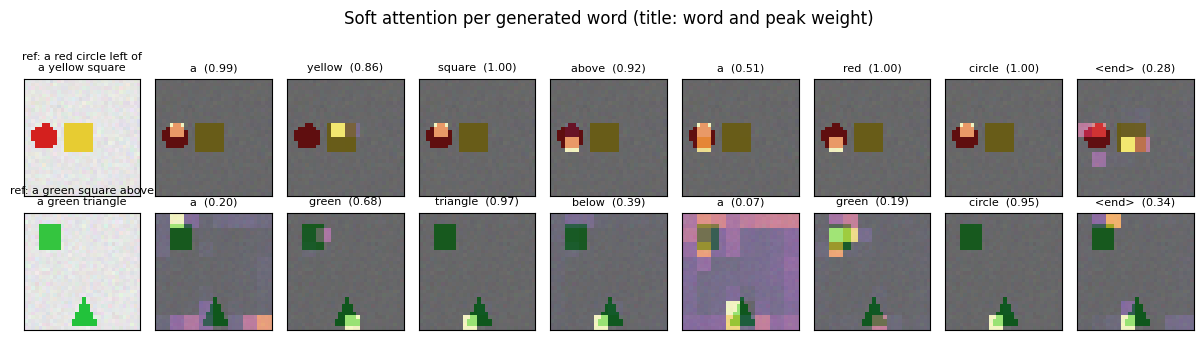

attention peak on the object being described (chance for a 3x3-cell object is about 0.14):
  subject words (colour, shape)  0.583
  relation word                  0.960
  object words (colour, shape)   0.846


In [22]:
def overlay(ax, img, alpha_map, title=None, side=8):
    """Draw the image with an attention map (L,) as a translucent heat map on top."""
    show_img(ax, img, title)
    up = np.kron(alpha_map.reshape(side, side), np.ones((IMG // side, IMG // side)))
    ax.imshow(up, cmap='inferno', alpha=0.55, vmin=0, vmax=max(up.max(), 1e-6), interpolation='nearest')

def attention_row(axes, img, ids, maps, ref):
    words = [VOCAB[i] for i in ids]
    n_words = words.index('<end>') + 1 if '<end>' in words else len(words)
    show_img(axes[0], img, 'ref: ' + ref.replace(' a ', '\na '))
    for j in range(1, len(axes)):
        if j <= n_words:
            overlay(axes[j], img, maps[j - 1], f'{words[j - 1]}  ({maps[j - 1].max():.2f})')
        else:
            axes[j].axis('off')

M_soft_np = M_soft.detach().cpu().numpy(); P_soft_np = P_soft.detach().cpu().numpy()
fig, axes = plt.subplots(2, 9, figsize=(12, 3.3))
for r, i in enumerate([0, 1]):
    attention_row(axes[r], Xte[i], P_soft_np[i], M_soft_np[i], refs_te[i][0])
fig.suptitle('Soft attention per generated word (title: word and peak weight)', y=1.02)
plt.tight_layout(); plt.show()

def peak_on_object(P_np, M_np):
    """How often the attention peak lands on the object being described (within 1.5 cells of its centre)."""
    hits = {'subject words (colour, shape)': [], 'relation word': [], 'object words (colour, shape)': []}
    for i in range(N_TEST):
        p = parse_caption(decode_ids(P_np[i].tolist()))
        if p is None:
            continue
        k = 5 if p['rel'] in ('left of', 'right of') else 4
        centre = {key: next(((o['cy'] / 4, o['cx'] / 4) for o in objs_te[i] if (o['color'], o['shape']) == p[key]), None)
                  for key in ('subj', 'obj')}
        near = lambda t, c: c is not None and abs(divmod(int(M_np[i][t].argmax()), 8)[0] + 0.5 - c[0]) <= 1.5 \
                            and abs(divmod(int(M_np[i][t].argmax()), 8)[1] + 0.5 - c[1]) <= 1.5
        for t in (1, 2):
            if centre['subj'] is not None: hits['subject words (colour, shape)'].append(near(t, centre['subj']))
        if centre['subj'] is not None or centre['obj'] is not None:
            hits['relation word'].append(near(3, centre['subj']) or near(3, centre['obj']))
        for t in (k + 1, k + 2):
            if centre['obj'] is not None: hits['object words (colour, shape)'].append(near(t, centre['obj']))
    return {k_: float(np.mean(v)) for k_, v in hits.items()}

loc_soft = peak_on_object(P_soft_np, M_soft_np)
print('attention peak on the object being described (chance for a 3x3-cell object is about 0.14):')
for k_, v in loc_soft.items():
    print(f'  {k_:30s} {v:.3f}')

### Widget 4: step through the attention maps

Pick a scene and drag `step` through the generated words. The left panel is the map for the current word, the right panel the whole caption with that word in brackets. Watch where the peak weight goes when the model says a colour, a shape, and the relation word, and check the failure scenes listed in the printout of Section 3.2.

In [23]:
def attention_step(index=0, step=1):
    ids = P_soft_np[index]; words = [VOCAB[i] for i in ids]
    n_words = words.index('<end>') + 1 if '<end>' in words else len(words)
    step = min(step, n_words)
    fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.2))
    overlay(axes[0], Xte[index], M_soft_np[index][step - 1], f'word {step}: "{words[step - 1]}"  (peak {M_soft_np[index][step - 1].max():.2f})')
    show_img(axes[1], Xte[index], 'test scene %d' % index)
    plt.tight_layout(); plt.show()
    shown = ' '.join(f'[{w}]' if j == step - 1 else w for j, w in enumerate(words[:n_words]))
    print('caption   :', shown, '  ->', 'OK' if caps_soft[index] in refs_te[index] else 'BAD')
    print('references:', ' | '.join(refs_te[index]))

interact(attention_step, index=IntSlider(min=0, max=N_TEST - 1, step=1, value=0, continuous_update=False),
         step=IntSlider(min=1, max=T_MAX, step=1, value=1, continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='index', max=399), IntSlider(val…

### 4.4 The failure cases, revisited

Now the failures of the attention model can be read. For each of the first four wrong captions we show the map at the first word that disagrees with the closest reference. When the map sits on the wrong object, the failure is *possible to understand*: the model looked at the wrong thing; when the map is diffuse, the model was not looking anywhere in particular and guessed.

soft-attention captions on the test set:
  correct               237  (59.2%)
  wrong relation        123  (30.8%)
  wrong shape            22  (5.5%)
  wrong colour           14  (3.5%)
  same object twice       3  (0.8%)
  hallucinated object     1  (0.2%)


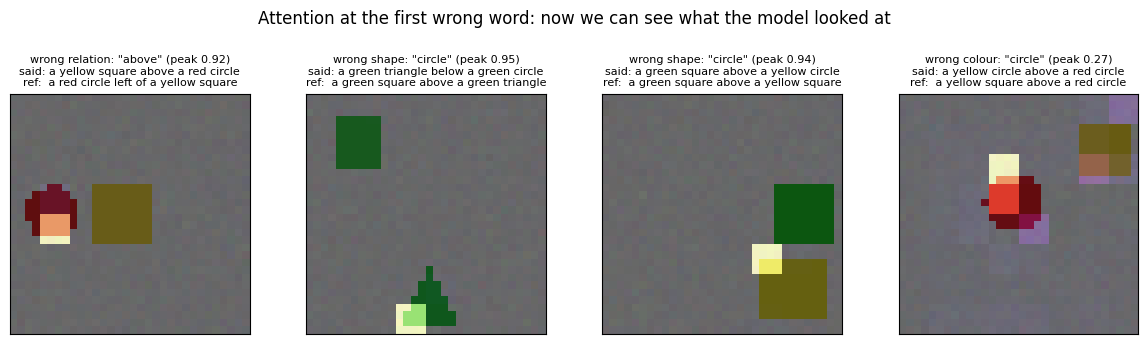

In [24]:
fail_soft = [classify_failure(c, o, r) for c, o, r in zip(caps_soft, objs_te, refs_te)]
print('soft-attention captions on the test set:')
for kind, cnt in Counter(fail_soft).most_common():
    print(f'  {kind:20s} {cnt:4d}  ({100 * cnt / N_TEST:.1f}%)')

def first_disagreement(cap, refs):
    """Index of the first word where the caption departs from the reference it matches longest."""
    w = cap.split(); best = 0
    for r in refs:
        rw = r.split(); j = 0
        while j < min(len(w), len(rw)) and w[j] == rw[j]:
            j += 1
        best = max(best, j)
    return min(best, len(w) - 1)

fail_idx_soft = [i for i, k in enumerate(fail_soft) if k != 'correct'][:4]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, i in zip(axes, fail_idx_soft):
    j = first_disagreement(caps_soft[i], refs_te[i]); words = caps_soft[i].split()
    overlay(ax, Xte[i], M_soft_np[i][j], f'{fail_soft[i]}: "{words[j]}" (peak {M_soft_np[i][j].max():.2f})\nsaid: {caps_soft[i]}\nref:  {refs_te[i][0]}')
fig.suptitle('Attention at the first wrong word: now we can see what the model looked at', y=1.06)
plt.tight_layout(); plt.show()

### 4.5 A measured claim: a weighted average forgets where it looked

Section 4.2 appended coordinates to the annotation vectors. Here is the same model trained for the same 12 epochs on the raw 48-dimensional annotations. The failure breakdown makes the point better than the exact-match number: without coordinates the model still names the right objects (it attends to them and reads their colour and shape), but the **relation** word, which needs the two positions, becomes a guess. The flattened image vector of Show and Tell keeps every cell in a fixed slot, so it never had this problem; attention has to be told where each annotation came from.

In [25]:
set_seed(0)
soft_nopos = AttnCaptioner('soft', D=D_ANN).to(device)
train_model(soft_nopos, lambda m, idx: caption_loss(m(Ftr[idx], Ytr[idx])[0], Ytr[idx]), N_TRAIN, epochs=12, bs=64,
            label='soft attention without coordinates', print_every=0)
P_nopos, M_nopos = soft_nopos.decode(Fte)
caps_nopos = captions_of(P_nopos)
fail_nopos = Counter(classify_failure(c, o, r) for c, o, r in zip(caps_nopos, objs_te, refs_te))
fail_pos = Counter(fail_soft)
print(f'\n{"soft attention":28s} {"exact":>7s} {"BLEU-4":>7s} {"wrong relation":>15s} {"wrong colour/shape":>19s} {"peak alpha":>11s}')
for name, caps, fails, M in [('with coordinates (4.2)', caps_soft, fail_pos, M_soft), ('without coordinates', caps_nopos, fail_nopos, M_nopos)]:
    print(f'{name:28s} {exact_match(caps, refs_te):7.3f} {bleu(caps, refs_te)[3]:7.3f} {fails["wrong relation"]:15d} '
          f'{fails["wrong colour"] + fails["wrong shape"]:19d} {M.max(-1).values.mean().item():11.3f}')
print(f'{"Show and Tell (Section 1)":28s} {acc_st:7.3f} {bleu_st[3]:7.3f} {Counter(fail_st)["wrong relation"]:15d} '
      f'{Counter(fail_st)["wrong colour"] + Counter(fail_st)["wrong shape"]:19d}')
assert fail_nopos['wrong relation'] > 1.5 * fail_pos['wrong relation'], 'coordinates should remove a large share of the relation errors'

soft attention without coordinates: 12 epochs in 6.4 s, loss 1.031 -> 0.263

soft attention                 exact  BLEU-4  wrong relation  wrong colour/shape  peak alpha
with coordinates (4.2)         0.593   0.768             123                  36       0.659
without coordinates            0.330   0.623             231                  32       0.559
Show and Tell (Section 1)      0.562   0.795              63                 111


## 5. Hard attention and the REINFORCE estimator

The slides show soft and hard attention as two pictures, diffuse grey blobs versus a single sharp spot, but do not define them symbolically. Lecture 1 of this week gives the definitions, so we use those:

- **soft**: every location gets a partial weight in $(0, 1)$; deterministic, differentiable.
- **hard**: one location is chosen with weight 1.0; stochastic, non-differentiable.

The two are connected by an expectation. If $s_t$ is a one-hot vector sampled from the distribution $\alpha_t$, then

$$\mathbb{E}[\hat z_t] = \mathbb{E}\Big[\sum_i s_{t,i} v_i\Big] = \sum_i \alpha_{t,i} v_i = z_t,$$

so **hard attention is an unbiased estimator of soft attention**. That is checkable by Monte Carlo.

In [26]:
# Hard attention is unbiased for soft attention: verify by sampling.
torch.manual_seed(0)
L_small, D_small = 16, 8
V_s = torch.randn(L_small, D_small)
a_s = torch.softmax(torch.randn(L_small), dim=0)

z_soft = a_s @ V_s                             # the deterministic weighted average

for n_samples in (10, 100, 1000, 10000, 100000):
    idx = torch.multinomial(a_s, n_samples, replacement=True)
    z_hard_mean = V_s[idx].mean(0)             # average of the sampled one-hot picks
    err = (z_hard_mean - z_soft).norm() / z_soft.norm()
    print(f'  {n_samples:6d} hard samples -> relative error vs soft attention {err:.4f}')

idx = torch.multinomial(a_s, 200000, replacement=True)
assert (V_s[idx].mean(0) - z_soft).norm() / z_soft.norm() < 0.02, 'hard attention is not unbiased'
print('\n  the sample mean converges to the soft context vector, as the expectation predicts')

      10 hard samples -> relative error vs soft attention 0.6982
     100 hard samples -> relative error vs soft attention 0.1396
    1000 hard samples -> relative error vs soft attention 0.1302
   10000 hard samples -> relative error vs soft attention 0.0339
  100000 hard samples -> relative error vs soft attention 0.0087

  the sample mean converges to the soft context vector, as the expectation predicts


But being unbiased in the forward pass does not make hard attention trainable. Sampling a location is not differentiable, so the gradient of the loss with respect to the attention logits is simply not there, as the next cell shows.

In [27]:
# But only one of them lets a gradient through.
a_logits = torch.randn(L_small, requires_grad=True)

soft_z = torch.softmax(a_logits, dim=0) @ V_s
soft_z.sum().backward()
print(f'  soft attention : gradient w.r.t. the attention logits, norm = {a_logits.grad.norm():.4f}')

a_logits.grad = None
with torch.no_grad():
    pick = torch.multinomial(torch.softmax(a_logits, dim=0), 1)
hard_z = V_s[pick].squeeze(0)
print(f'  hard attention : sampled context requires_grad = {hard_z.requires_grad}')
print('\n  soft attention trains by ordinary backpropagation;')
print('  hard attention needs an estimator that the slides do not cover')

  soft attention : gradient w.r.t. the attention logits, norm = 0.9123
  hard attention : sampled context requires_grad = False

  soft attention trains by ordinary backpropagation;
  hard attention needs an estimator that the slides do not cover


### 5.1 The score-function (REINFORCE) estimator

Xu et al. train hard attention with the estimator the slides leave out. Write the expected loss over the sampled location as $J(\theta) = \mathbb{E}_{s \sim p_\theta}[f(s)]$. Its gradient has a form that only needs $\nabla_\theta \log p_\theta(s)$, which *is* differentiable:

$$\nabla_\theta J = \sum_s f(s) \nabla_\theta p_\theta(s) = \sum_s p_\theta(s)\, f(s)\, \nabla_\theta \log p_\theta(s) = \mathbb{E}_{s \sim p_\theta}\big[f(s)\, \nabla_\theta \log p_\theta(s)\big].$$

So sample locations, weight each sample's $\nabla \log p$ by its reward $f(s)$, and average. Subtracting a **baseline** $b$ from $f(s)$ leaves the expectation unchanged (because $\mathbb{E}[\nabla \log p] = 0$) but can shrink the variance a lot, especially when all rewards share a large offset, which is exactly what a log-likelihood reward looks like (every $\log p$ is a negative number of similar size). The cell below checks both facts on six locations, where the exact gradient can be computed by enumerating every outcome, and also computes the variance-minimising constant baseline $b^* = \mathbb{E}[f(s)\,\|\nabla \log p(s)\|^2] / \mathbb{E}[\|\nabla \log p(s)\|^2]$.

In [28]:
set_seed(0)
n_loc = 6
theta = torch.randn(n_loc, requires_grad=True)          # attention logits over 6 locations (CPU: no model involved)
f_val = torch.randn(n_loc) * 2 - 8                      # rewards with a large shared offset, like log-likelihoods
p = torch.softmax(theta, 0)
exact_grad = torch.autograd.grad((p * f_val).sum(), theta)[0]          # enumerate all 6 outcomes

n_samp = 20000
s = torch.multinomial(p.detach(), n_samp, replacement=True)
logp_s = torch.log_softmax(theta, 0)[s]
b_mean = (p.detach() * f_val).sum().item()                                          # baseline b = E[f]
est_raw = torch.autograd.grad((f_val[s] * logp_s).mean(), theta, retain_graph=True)[0]   # score-function estimate, no baseline
est_base = torch.autograd.grad(((f_val[s] - b_mean) * logp_s).mean(), theta)[0]    # the same with the baseline
err_raw = ((est_raw - exact_grad).norm() / exact_grad.norm()).item()
err_base = ((est_base - exact_grad).norm() / exact_grad.norm()).item()
assert err_base < 0.05, 'REINFORCE estimate (with baseline) disagrees with the exact gradient'

# Per-sample gradients in closed form: grad log p(s) = onehot(s) - p. A baseline changes the variance, not the mean.
onehot = F.one_hot(s, n_loc).float() - p.detach()
score_sq = (onehot ** 2).sum(1)
b_opt = ((f_val[s] * score_sq).mean() / score_sq.mean()).item()      # the variance-minimising constant baseline
variances = {}
for b_name, b in [('no baseline', 0.0), ('baseline = E[f]', (p.detach() * f_val).sum().item()), ('optimal baseline', b_opt)]:
    g = (f_val[s] - b).unsqueeze(1) * onehot
    variances[b_name] = g.var(0).sum().item()
    print(f'  {b_name:17s} (b = {b:6.2f}): per-sample gradient variance {variances[b_name]:8.3f}')
assert variances['baseline = E[f]'] < 0.2 * variances['no baseline'], 'the baseline should cut the variance'
print(f'score-function estimate with {n_samp} samples: relative error vs the exact gradient '
      f'{err_raw:.3f} without a baseline, {err_base:.3f} with b = E[f]  (both unbiased; the baseline only changes the variance)')

  no baseline       (b =   0.00): per-sample gradient variance   37.625
  baseline = E[f]   (b =  -7.60): per-sample gradient variance    0.592
  optimal baseline  (b =  -7.92): per-sample gradient variance    0.534
score-function estimate with 20000 samples: relative error vs the exact gradient 0.106 without a baseline, 0.008 with b = E[f]  (both unbiased; the baseline only changes the variance)


### 5.2 Training hard attention, and comparing it with soft on the same data

The hard-attention loss has two parts. The word loss is the usual cross-entropy, now computed with a **sampled** location at every step. The attention logits receive the REINFORCE term

$$-\lambda \sum_t \hat A_t \log p(s_t), \qquad \hat A_t = \frac{r_t - b_t}{\mathrm{std}(r - b)},$$

where the reward $r_t$ is the log-probability of the correct word right after attending to $s_t$, $b_t$ is a moving average of that reward per step, the advantage $r_t - b_t$ is divided by its standard deviation over the batch, and $\lambda = 0.3$ weights the term against the word loss. Two of Xu et al.'s variance-reduction tricks are used, the moving-average baseline and feeding the **expected** context with probability 0.5 during training, so that the word model does not have to learn from pure noise; in place of their entropy regulariser on the location distribution we normalise the advantage and weight the term by $\lambda$. At test time the hard model picks the argmax location.

The comparison is on identical data (the coordinate-augmented annotations of Section 4.2), the same number of epochs and the same batch size, so the difference is the estimator.

In [29]:
def hard_loss_factory(lam=0.3, mix=0.5):
    baseline = {'b': None}
    def fwd(model, idx):
        logits, alphas, logps = model(Ftr_pos[idx], Ytr[idx], sample=True, mix=mix)
        Yt = Ytr[idx][:, 1:]; mask = (Yt != PAD).float()
        nll = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), Yt.reshape(-1), ignore_index=PAD, reduction='none').reshape(Yt.shape)
        word_loss = (nll * mask).sum() / mask.sum()
        reward = -(nll * mask).detach()                                       # log p(correct word) after looking at s_t
        baseline['b'] = reward.mean(0) if baseline['b'] is None else 0.9 * baseline['b'] + 0.1 * reward.mean(0)
        adv = reward - baseline['b']; adv = adv / (adv.std() + 1e-6)
        reinforce = -(adv * logps * mask).sum() / mask.sum()                   # score-function term
        return word_loss + lam * reinforce
    return fwd

set_seed(0)
hard = AttnCaptioner('hard', D=D_POS).to(device)
hist_hard = train_model(hard, hard_loss_factory(), N_TRAIN, epochs=12, bs=64, label='hard attention (REINFORCE)', print_every=3)
P_hard, M_hard = hard.decode(Fte_pos)
caps_hard = captions_of(P_hard); bleu_hard = bleu(caps_hard, refs_te); acc_hard = exact_match(caps_hard, refs_te)
peak_hard = M_hard.max(-1).values.mean().item()
ent = lambda M: (-(M * torch.log(M + 1e-9)).sum(-1)).mean().item()
print(f'\n{"":18s} {"exact":>7s} {"BLEU-1":>7s} {"BLEU-4":>7s} {"peak alpha":>11s} {"entropy":>8s}')
print(f'{"soft attention":18s} {acc_soft:7.3f} {bleu_soft[0]:7.3f} {bleu_soft[3]:7.3f} {peak_soft:11.3f} {ent(M_soft):8.3f}')
print(f'{"hard attention":18s} {acc_hard:7.3f} {bleu_hard[0]:7.3f} {bleu_hard[3]:7.3f} {peak_hard:11.3f} {ent(M_hard):8.3f}')
print(f'(entropy of a uniform map over {L_GRID} locations: {math.log(L_GRID):.3f} nats)')
fail_hard = Counter(classify_failure(c, o, r) for c, o, r in zip(caps_hard, objs_te, refs_te))
print('\nfailure breakdown, soft vs hard: ' + ' | '.join(f'{k_} {Counter(fail_soft)[k_]} vs {fail_hard[k_]}'
      for k_ in ('correct', 'wrong relation', 'wrong colour', 'wrong shape', 'same object twice')))

  epoch  3: train loss 0.468


  epoch  6: train loss 0.351


  epoch  9: train loss 0.314


  epoch 12: train loss 0.301
hard attention (REINFORCE): 12 epochs in 7.1 s, loss 1.675 -> 0.301

                     exact  BLEU-1  BLEU-4  peak alpha  entropy
soft attention       0.593   0.916   0.768       0.659    1.279
hard attention       0.330   0.903   0.622       0.682    1.177
(entropy of a uniform map over 64 locations: 4.159 nats)

failure breakdown, soft vs hard: correct 237 vs 132 | wrong relation 123 vs 191 | wrong colour 14 vs 43 | wrong shape 22 vs 22 | same object twice 3 vs 12


The gap is large on our budget: the estimator is noisy, and a decoder that consumes one sampled cell per step gets less of the scene than one that consumes a weighted average, so the relation word, which needs both objects, suffers most (the failure breakdown above shows where the two models differ). Xu et al. report hard attention slightly ahead of soft on Flickr8k, Flickr30k and COCO, but with far more data and training, and it needs the moving-average baseline, an entropy regulariser on the location distribution and the expected-context mixing to train at all.

The static comparison below shows, for one scene and one word, the soft map, the hard model's map with its argmax location, and two locations sampled from that map, which is what the hard model actually consumed during training.

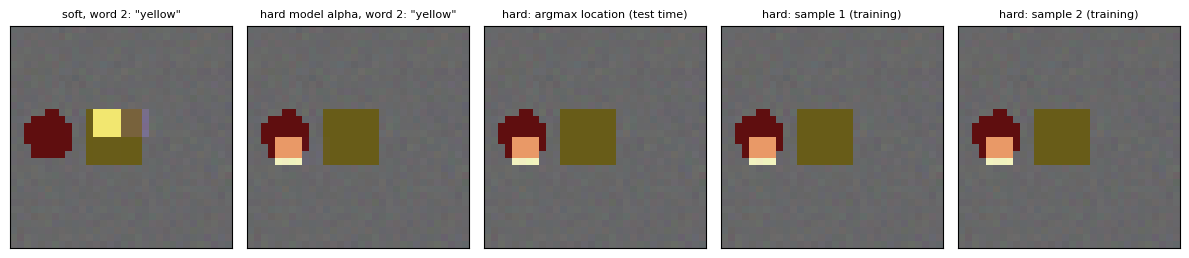

soft caption: "a yellow square above a red circle"   hard caption: "a yellow square above a red circle"   references: ['a red circle left of a yellow square', 'a yellow square right of a red circle']


In [30]:
M_hard_np = M_hard.detach().cpu().numpy(); P_hard_np = P_hard.detach().cpu().numpy()

def hard_samples(alpha_map, n=3, seed=0):
    g = torch.Generator().manual_seed(seed)
    return torch.multinomial(torch.tensor(alpha_map), n, replacement=True, generator=g).tolist()

def one_hot_map(loc):
    m = np.zeros(L_GRID, np.float32); m[loc] = 1.0; return m

def soft_vs_hard_figure(index, step):
    ws, wh = [VOCAB[i] for i in P_soft_np[index]], [VOCAB[i] for i in P_hard_np[index]]
    fig, axes = plt.subplots(1, 5, figsize=(12, 2.8))
    overlay(axes[0], Xte[index], M_soft_np[index][step - 1], f'soft, word {step}: "{ws[step - 1]}"')
    overlay(axes[1], Xte[index], M_hard_np[index][step - 1], f'hard model alpha, word {step}: "{wh[step - 1]}"')
    overlay(axes[2], Xte[index], one_hot_map(int(M_hard_np[index][step - 1].argmax())), 'hard: argmax location (test time)')
    for j, loc in enumerate(hard_samples(M_hard_np[index][step - 1], 2)):
        overlay(axes[3 + j], Xte[index], one_hot_map(loc), f'hard: sample {j + 1} (training)')
    plt.tight_layout(); plt.show()
    print(f'soft caption: "{caps_soft[index]}"   hard caption: "{caps_hard[index]}"   references: {refs_te[index]}')

soft_vs_hard_figure(0, 2)

### Widget 5: soft versus hard

Choose a scene and a word position. Soft attention spreads its weight (and consumes the average); the hard model's distribution is slightly sharper, but what it consumed during training was one sampled cell at a time, and the samples change with the seed. Try the relation word (position 4), where neither model has a single obvious place to look.

In [31]:
interact(soft_vs_hard_figure, index=IntSlider(min=0, max=N_TEST - 1, step=1, value=0, continuous_update=False),
         step=IntSlider(min=1, max=8, step=1, value=2, continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='index', max=399), IntSlider(val…

## 6. Boosting captioning with attributes: LSTM-A1 to A5

*Yao et al., ICCV 2017* ask a simpler question than attention. Besides the image vector $\mathbf{I}$, an **attribute detector** provides a vector $\mathbf{A}$ of high-level attributes (in the paper, probabilities of 1000 words being in the caption; here, our attribute network's seven probabilities). Both are available, so where in the sequence should each be fed? The paper enumerates five answers, all as changes to the LSTM's **input schedule**:

| Variant | Injection |
|---|---|
| **LSTM** (baseline) | image at $t = -1$, nothing else |
| **A1** | attributes at $t = -1$, nothing else |
| **A2** | image at $t = -2$, then attributes at $t = -1$ |
| **A3** | attributes at $t = -2$, then image at $t = -1$ |
| **A4** | attributes at $t = -1$, image added at **every** step |
| **A5** | image at $t = -1$, attributes added at **every** step |

The reported ordering is A1 > LSTM, A2 > A1, A3 > A2, A4 < A3 and A5 > A3; the slides explain A4's weakness as noise in the image accumulating when it is injected repeatedly, and read A2, A3, A5 > LSTM as evidence that image and attributes are complementary. The cell below is the schedule written as a list of inputs, with the paper's input dimensions (a 1024-dimensional image vector and a 1000-dimensional attribute vector).

In [32]:
# The five variants as input schedules. Only the schedule differs.
D_v, D_a, D_s, Hh2 = 1024, 1000, 300, 512
T_cap = 6

T_v = torch.randn(Hh2, D_v) * 0.02             # image projection
T_a = torch.randn(Hh2, D_a) * 0.02             # attribute projection
T_s = torch.randn(Hh2, D_s) * 0.02             # word projection

I = torch.randn(D_v); A = torch.randn(D_a)
words = torch.randn(T_cap, D_s)

def schedule(variant):
    """Return the list of LSTM inputs, in order, for one variant."""
    pre, per_step = [], torch.zeros(Hh2)
    if variant == 'A1': pre = [T_a @ A]
    elif variant == 'A2': pre = [T_v @ I, T_a @ A]
    elif variant == 'A3': pre = [T_a @ A, T_v @ I]
    elif variant == 'A4': pre, per_step = [T_a @ A], T_v @ I
    elif variant == 'A5': pre, per_step = [T_v @ I], T_a @ A
    return pre + [T_s @ w + per_step for w in words]

for v_ in ('A1', 'A2', 'A3', 'A4', 'A5'):
    seq = schedule(v_)
    extra = len(seq) - T_cap
    repeated = 'yes' if v_ in ('A4', 'A5') else 'no '
    print(f'  {v_}: {len(seq)} inputs ({extra} before the first word), repeated injection: {repeated}')

assert len(schedule('A1')) == T_cap + 1
assert len(schedule('A2')) == len(schedule('A3')) == T_cap + 2
print('\n  A2 and A3 feed the same two vectors and differ only in ORDER,')
print('  yet the slides report A3 > A2 - the order of injection matters')

  A1: 7 inputs (1 before the first word), repeated injection: no 
  A2: 8 inputs (2 before the first word), repeated injection: no 
  A3: 8 inputs (2 before the first word), repeated injection: no 
  A4: 7 inputs (1 before the first word), repeated injection: yes
  A5: 7 inputs (1 before the first word), repeated injection: yes

  A2 and A3 feed the same two vectors and differ only in ORDER,
  yet the slides report A3 > A2 - the order of injection matters


### 6.1 One decoder, six schedules, measured

Now the real thing: an LSTM decoder whose only difference between variants is `schedule()`. The prefix inputs are pushed through the cell before the first word; the per-step vector, when the variant has one, is added to every word embedding. The attribute input is the **predicted** attribute vector from Section 1.2, not the ground truth, so the detector's mistakes are part of the experiment as they are in the paper. Because Section 1.4 showed that an LSTM trained from scratch tends to forget a once-injected input, all six variants use an LSTM whose gate biases start open (input and output at $+2$, forget at $+3$), which is the standard remedy; all six share it, so the comparison stays fair.

All six train for the same 8 epochs on the same data.

In [33]:
class LSTMA(nn.Module):
    """Yao et al.'s LSTM-A family: the variant only changes the input schedule."""
    def __init__(self, variant='LSTM', n_vocab=len(VOCAB), D=D_ANN, L=L_GRID, E=64, H=96, n_attr=7, DV=64, gate_bias=(2.0, 3.0, 2.0)):
        super().__init__()
        self.variant = variant; self.H = H
        self.fc = nn.Linear(D * L, DV); self.emb = nn.Embedding(n_vocab, E)
        self.Tv = nn.Linear(DV, E); self.Ta = nn.Linear(n_attr, E)           # image and attribute projections
        self.cell = nn.LSTMCell(E, H); self.out = nn.Linear(H, n_vocab)
        self.noise = 0.0; self.fresh = True                                  # test-time noise on the image vector (6.3); fresh: redrawn per step
        with torch.no_grad():
            self.cell.bias_hh.zero_(); self.cell.bias_ih.zero_()
            self.cell.bias_ih[:H].fill_(gate_bias[0]); self.cell.bias_ih[H:2 * H].fill_(gate_bias[1]); self.cell.bias_ih[3 * H:].fill_(gate_bias[2])
    def image_vector(self, f):
        return torch.relu(self.fc(f.flatten(1)))
    def noisy(self, v):
        """Test-time corruption (6.3): a fresh Gaussian draw every time the image vector is fed to the cell."""
        return v + self.noise * torch.randn_like(v) if self.noise > 0 else v
    def schedule(self, f, A_):
        """Prefix inputs (fed before the first word), the per-step vector (None if not repeated), the clean image vector."""
        v = self.image_vector(f)
        vi, a = self.Tv(self.noisy(v)), self.Ta(A_)
        pre = {'LSTM': [vi], 'A1': [a], 'A2': [vi, a], 'A3': [a, vi], 'A4': [a], 'A5': [vi]}[self.variant]
        per = {'A4': vi, 'A5': a}.get(self.variant)
        return pre, per, v
    def init_state(self, f, A_):
        pre, per, v = self.schedule(f, A_); n = f.shape[0]
        h = torch.zeros(n, self.H, device=f.device); c = torch.zeros(n, self.H, device=f.device)
        for x_ in pre:
            h, c = self.cell(x_, (h, c))
        return (h, c, per if per is not None else torch.zeros(n, self.emb.embedding_dim, device=f.device), v)
    def per_step(self, state):
        """The vector added to this step's word embedding. Under noise, A4 either re-draws the image noise at every
        step (fresh = True) or repeats the one noisy vector drawn in schedule() (fresh = False)."""
        per, v = state[2], state[3]
        return self.Tv(self.noisy(v)) if (self.variant == 'A4' and self.noise > 0 and self.fresh) else per
    def step(self, tok, state):
        h, c = self.cell(self.emb(tok) + self.per_step(state), (state[0], state[1]))
        return F.log_softmax(self.out(h), -1), (h, c, state[2], state[3])
    def forward(self, f, A_, Y):
        state = self.init_state(f, A_); hs = []
        for t in range(Y.shape[1] - 1):
            h, c = self.cell(self.emb(Y[:, t]) + self.per_step(state), (state[0], state[1])); state = (h, c, state[2], state[3]); hs.append(h)
        return self.out(torch.stack(hs, 1))

VARIANTS = ['LSTM', 'A1', 'A2', 'A3', 'A4', 'A5']
lstma, caps_a, res_a = {}, {}, {}
t0 = time.time()
for var in VARIANTS:
    set_seed(0)
    m = LSTMA(var).to(device)
    hist = train_model(m, lambda mm, idx: caption_loss(mm(Ftr[idx], Ahat_tr[idx], Ytr[idx]), Ytr[idx]), N_TRAIN, epochs=8, bs=64, label=f'  {var:5s}', print_every=0)
    caps_a[var] = captions_of(greedy_decode(m, m.init_state(Fte, Ahat_te)))
    res_a[var] = dict(exact=exact_match(caps_a[var], refs_te), bleu4=bleu(caps_a[var], refs_te)[3], loss=hist[-1]); lstma[var] = m
print(f'six variants trained in {time.time() - t0:.1f} s\n')
print(f'{"variant":8s} {"exact":>7s} {"BLEU-4":>7s} {"train loss":>11s}')
for var in VARIANTS:
    print(f'{var:8s} {res_a[var]["exact"]:7.3f} {res_a[var]["bleu4"]:7.3f} {res_a[var]["loss"]:11.3f}')
claims = [('A1 > LSTM', 'A1', 'LSTM'), ('A2 > A1', 'A2', 'A1'), ('A3 > A2', 'A3', 'A2'), ('A4 < A3', 'A3', 'A4'), ('A5 > A3', 'A5', 'A3')]
print('\nthe slide\'s observations, checked on our exact-match numbers:')
for name, hi, lo in claims:
    print(f'  {name:9s} {"holds" if res_a[hi]["exact"] > res_a[lo]["exact"] else "does NOT hold here"}   ({hi} {res_a[hi]["exact"]:.3f} vs {lo} {res_a[lo]["exact"]:.3f})')

  LSTM : 8 epochs in 1.9 s, loss 1.038 -> 0.317


  A1   : 8 epochs in 1.8 s, loss 0.885 -> 0.305


  A2   : 8 epochs in 2.1 s, loss 0.942 -> 0.289


  A3   : 8 epochs in 2.2 s, loss 0.903 -> 0.278


  A4   : 8 epochs in 2.1 s, loss 1.055 -> 0.175


  A5   : 8 epochs in 2.0 s, loss 0.849 -> 0.290
six variants trained in 12.3 s

variant    exact  BLEU-4  train loss
LSTM       0.263   0.560       0.317
A1         0.245   0.538       0.305
A2         0.278   0.563       0.289
A3         0.343   0.610       0.278
A4         0.583   0.820       0.175
A5         0.295   0.577       0.290

the slide's observations, checked on our exact-match numbers:
  A1 > LSTM does NOT hold here   (A1 0.245 vs LSTM 0.263)
  A2 > A1   holds   (A2 0.278 vs A1 0.245)
  A3 > A2   holds   (A3 0.343 vs A2 0.278)
  A4 < A3   does NOT hold here   (A3 0.343 vs A4 0.583)
  A5 > A3   does NOT hold here   (A5 0.295 vs A3 0.343)


### 6.2 What holds and what does not

Two of the paper's five observations survive in our setting and three do not, and the reasons are instructive.

- **A2 > A1 and A3 > A2 hold.** Adding the image to the attributes helps, and feeding the attributes first and the image last helps more: the image is the more recent input when the first word is produced.
- **A1 > LSTM does not hold** (0.245 against 0.263). The paper's attributes are 1000 words predicted by a multiple-instance detector and they carry most of a COCO caption. Ours are seven presence bits: they name the two objects but say nothing about where they are, so the relation word, one fifth of every caption, is a guess. A1 cannot beat a model that sees the image at all.
- **A4 < A3 does not hold**; A4 is the best variant by a wide margin (0.583). Section 1.4 explains why: in a small LSTM trained from scratch an input fed once is quickly forgotten, and A4 is the only variant that keeps re-feeding the image. On COCO, with pretrained features and a large LSTM trained for days, that advantage disappears and the paper's overfitting argument takes over.
- **A5 > A3 does not hold** (0.295 against 0.343): repeating seven presence bits at every step adds nothing the LSTM did not already have from $t = -1$.

The interesting question is whether the paper's *mechanism* for A4's weakness, noise accumulating with repeated injection, is real even in a setting where A4 wins. The next cell tests it.

### 6.3 The A4 claim: does injected image noise accumulate?

The slides explain A4 < A3 by noise in the image representation being *"explicitly accumulated"* when the image is fed at every step. We can test the mechanism directly. Add Gaussian noise of standard deviation $\sigma$ to the image vector at **test time** and watch exact match fall: a model that consumes the image once (A3) sees one noisy vector, a model that consumes it at every step (A4) sees a noisy vector at every step, up to nine times per caption. There are two readings of that sentence, and we measure both: the noise is **redrawn** each time the image is fed, or the **same** noisy vector is repeated, which is what a fixed error in the features of one image looks like. If the slide's mechanism is real, A4's curve should fall faster than A3's even when A4 starts higher, and faster than its larger dependence on the image alone would explain; the cell therefore also prints that dependence, the exact match each variant gains over A1 (which sees no image), so that the drops can be compared as a share of it.

  LSTM                     exact match at sigma = 0.0: 0.263, 0.25: 0.263, 0.5: 0.263, 1.0: 0.265, 2.0: 0.255
  A3                       exact match at sigma = 0.0: 0.343, 0.25: 0.340, 0.5: 0.335, 1.0: 0.323, 2.0: 0.307
  A4                       exact match at sigma = 0.0: 0.583, 0.25: 0.600, 0.5: 0.593, 1.0: 0.573, 2.0: 0.510
  A5                       exact match at sigma = 0.0: 0.295, 0.25: 0.292, 0.5: 0.295, 1.0: 0.292, 2.0: 0.280
  A4, same noise repeated  exact match at sigma = 0.0: 0.583, 0.25: 0.573, 0.5: 0.575, 1.0: 0.547, 2.0: 0.420

drop from sigma = 0 to 2.0: A3 0.035 | A4 0.073 (noise redrawn per step), 0.163 (same noise repeated) | A5 0.015 (control: repeats the attributes, not the image)
the image adds 0.338 of exact match to A4 but only 0.098 to A3 (each over A1, which sees no image)
drop as a share of that gain: A3 0.36 | A4 0.21 (redrawn), 0.48 (repeated)


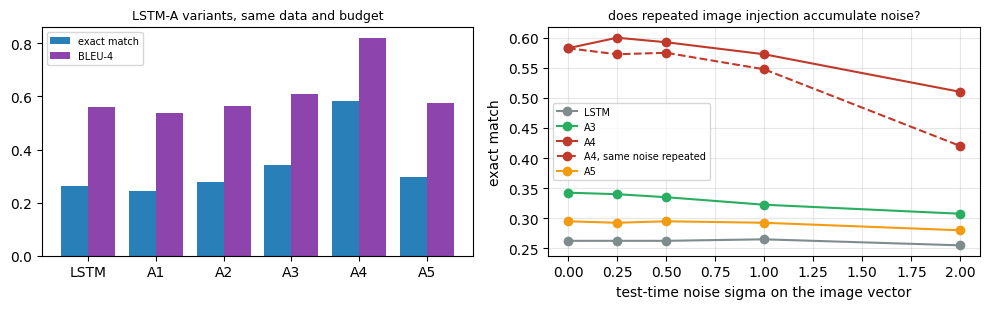

In [34]:
SIGMAS = [0.0, 0.25, 0.5, 1.0, 2.0]
A4_REP = 'A4, same noise repeated'

def noise_curve(m, fresh=True):
    """Exact match at every sigma; fresh = False repeats one noisy vector at every step instead of redrawing it."""
    accs = []
    for sg in SIGMAS:
        set_seed(0); m.noise, m.fresh = sg, fresh
        accs.append(exact_match(captions_of(greedy_decode(m, m.init_state(Fte, Ahat_te))), refs_te))
    m.noise, m.fresh = 0.0, True
    return accs

noise_curves = {var: noise_curve(lstma[var]) for var in ['LSTM', 'A3', 'A4', 'A5']}
noise_curves[A4_REP] = noise_curve(lstma['A4'], fresh=False)
for var, accs in noise_curves.items():
    print(f'  {var:24s} exact match at sigma = ' + ', '.join(f'{sg}: {a:.3f}' for sg, a in zip(SIGMAS, accs)))
drop = {v: noise_curves[v][0] - noise_curves[v][-1] for v in noise_curves}
gain = {v: res_a[v]['exact'] - res_a['A1']['exact'] for v in ('A3', 'A4')}      # what the image adds over attributes alone
print(f'\ndrop from sigma = 0 to {SIGMAS[-1]}: A3 {drop["A3"]:.3f} | A4 {drop["A4"]:.3f} (noise redrawn per step), {drop[A4_REP]:.3f} (same noise repeated) '
      f'| A5 {drop["A5"]:.3f} (control: repeats the attributes, not the image)')
print(f'the image adds {gain["A4"]:.3f} of exact match to A4 but only {gain["A3"]:.3f} to A3 (each over A1, which sees no image)')
print(f'drop as a share of that gain: A3 {drop["A3"] / gain["A3"]:.2f} | A4 {drop["A4"] / gain["A4"]:.2f} (redrawn), {drop[A4_REP] / gain["A4"]:.2f} (repeated)')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
xs = np.arange(len(VARIANTS))
axes[0].bar(xs - 0.2, [res_a[v]['exact'] for v in VARIANTS], 0.4, color='#2980b9', label='exact match')
axes[0].bar(xs + 0.2, [res_a[v]['bleu4'] for v in VARIANTS], 0.4, color='#8e44ad', label='BLEU-4')
axes[0].set_xticks(xs); axes[0].set_xticklabels(VARIANTS); axes[0].legend(fontsize=7); axes[0].set_title('LSTM-A variants, same data and budget', fontsize=9)
for var, col, ls in zip(['LSTM', 'A3', 'A4', A4_REP, 'A5'], ['#7f8c8d', '#27ae60', '#c0392b', '#c0392b', '#f39c12'], ['-', '-', '-', '--', '-']):
    axes[1].plot(SIGMAS, noise_curves[var], 'o', ls=ls, color=col, label=var)
axes[1].set_xlabel('test-time noise sigma on the image vector'); axes[1].set_ylabel('exact match'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
axes[1].set_title('does repeated image injection accumulate noise?', fontsize=9)
plt.tight_layout(); plt.show()

The result is consistent with the mechanism, but only in one of the two readings. In absolute terms A4 is the most fragile variant: with $\sigma = 2$ on the image vector it loses about 0.07 of exact match when the noise is redrawn at every step and about 0.16 when the same noisy vector is repeated, where A3 loses about 0.04 and A5, the control that repeats the attributes rather than the image, about 0.02. But A4 also depends on the image far more than A3 does: over A1, which sees no image, the image adds 0.34 to A4 and only 0.10 to A3, so a larger absolute drop is expected even without any accumulation. As a share of that contribution the picture splits. With independent noise at each step A4 gives up about 0.21 against A3's 0.36: the recurrence averages fresh draws out, and repeated injection is, if anything, the more robust design. With the same corruption repeated at every step A4 gives up about 0.48, and only there does the slide's accumulation show. In the paper's setting the error in an image's features is fixed, so the repeated reading is the relevant one and A4's sensitivity is in line with the slide's explanation, but our measurement is far from a clean confirmation: the effect is a fraction of what the raw drops suggest, and at $\sigma = 0.25$ a little noise even nudges A4 upward (0.60 against 0.58, within the standard error of about 0.025 for 400 scenes).

### Widget 6: the same scene through six schedules

Choose a scene and a variant. The bar chart marks the chosen variant; the list gives its caption and, for comparison, the captions of the other five. On scenes where the attribute detector is right, A1 already gets the objects right and only the relation word is a guess; on scenes where it is wrong, the variants that also see the image can recover.

In [35]:
def lstma_widget(index=0, variant='A3'):
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.0))
    show_img(axes[0], Xte[index], f'test scene {index}')
    cols = ['#c0392b' if v == variant else '#bdc3c7' for v in VARIANTS]
    axes[1].bar(VARIANTS, [res_a[v]['exact'] for v in VARIANTS], color=cols); axes[1].set_ylabel('exact match'); axes[1].set_ylim(0, 1)
    axes[1].set_title(f'{variant}: exact {res_a[variant]["exact"]:.3f}, BLEU-4 {res_a[variant]["bleu4"]:.3f}', fontsize=9)
    plt.tight_layout(); plt.show()
    print(f'predicted attributes: ' + ', '.join(f'{n}={p:.2f}' for n, p in zip(list(COLORS) + SHAPES, Ahat_te[index].tolist()) if p > 0.3))
    print('references          :', ' | '.join(refs_te[index]))
    for v in VARIANTS:
        mark = '>>' if v == variant else '  '
        print(f'{mark} {v:5s} {"OK " if caps_a[v][index] in refs_te[index] else "BAD"} "{caps_a[v][index]}"')

interact(lstma_widget, index=IntSlider(min=0, max=N_TEST - 1, step=1, value=0, continuous_update=False),
         variant=Dropdown(options=VARIANTS, value='A3', description='variant'));

interactive(children=(IntSlider(value=0, continuous_update=False, description='index', max=399), Dropdown(desc…

## 7. StyleNet and the factored LSTM

*Gan et al., CVPR 2017* want captions in a *style*: factual, romantic, humorous. Styled captions paired with images are rare, but styled **text** is plentiful, so StyleNet separates the two. Recall the LSTM's input transformation: four gates, each a matrix acting on the input $x_t$. StyleNet factors each input-to-hidden matrix into three:

$$\mathbf{W}_x = \mathbf{U}_x \mathbf{S}_x \mathbf{V}_x,$$

where $\mathbf{U}$ and $\mathbf{V}$ are shared across all styles and trained on factual image-caption pairs, while the small middle factor $\mathbf{S}_x$ is **style-specific** and the styled ones are trained on text alone, as a language model. At test time you **swap $\mathbf{S}_x$** to change the style, leaving everything else fixed. The cell below counts what the factorisation saves and checks that swapping $\mathbf{S}$ alone changes the output.

*A note on the slide's LSTM.* It prints $h_t = o_t \odot c_t$, without the $\tanh$, while the figure on the same slide clearly routes $c_t$ through a $\tanh$ first. The standard LSTM, Week 7 Lecture 3, and our cell below all use $h_t = o_t \odot \tanh(c_t)$.

In [36]:
# The factored matrix, and what swapping S alone does.
d_in, d_out, rank = 300, 512, 64

U = torch.randn(d_out, rank) * 0.05
V = torch.randn(rank, d_in) * 0.05
S_factual  = torch.randn(rank, rank) * 0.05
S_romantic = torch.randn(rank, rank) * 0.05

W_factual  = U @ S_factual  @ V
W_romantic = U @ S_romantic @ V
assert W_factual.shape == (d_out, d_in) == W_romantic.shape

x = torch.randn(d_in)
diff = (W_factual @ x - W_romantic @ x).norm() / (W_factual @ x).norm()
assert diff > 0.1, 'swapping S should change the output'

dense = d_out * d_in
factored_shared = U.numel() + V.numel()
per_style = S_factual.numel()

print(f'  dense W          : {dense:,} parameters')
print(f'  factored U, V    : {factored_shared:,} shared across every style')
print(f'  one S per style  : {per_style:,}')
print(f'\n  three styles cost {factored_shared + 3 * per_style:,} factored'
      f' vs {3 * dense:,} dense ({3 * dense / (factored_shared + 3 * per_style):.1f}x saving)')
print(f'  swapping S alone changes the output by {100 * diff:.0f}%')

  dense W          : 153,600 parameters
  factored U, V    : 51,968 shared across every style
  one S per style  : 4,096

  three styles cost 64,256 factored vs 460,800 dense (7.2x saving)
  swapping S alone changes the output by 125%


### 7.1 A factored LSTM cell, verified

The cell computes the four gates as $\mathbf{U} \mathbf{S}_{\text{style}} \mathbf{V} x_t + \mathbf{W}_h h_{t-1} + b$, with one $\mathbf{S}$ per style stored in a `ParameterDict`. Copying $\mathbf{W}_x = \mathbf{U}\mathbf{S}\mathbf{V}$ into an `nn.LSTMCell` must reproduce its output exactly.

In [37]:
class FactoredLSTMCell(nn.Module):
    """LSTM cell whose input-to-hidden matrix is W_x = U S V; S is the style-specific factor (Gan et al.)."""
    def __init__(self, E, H, rank, styles=('factual', 'romantic')):
        super().__init__()
        self.H = H
        self.U = nn.Parameter(torch.randn(4 * H, rank) / math.sqrt(rank))
        self.V = nn.Parameter(torch.randn(rank, E) / math.sqrt(E))
        self.S = nn.ParameterDict({s: nn.Parameter(torch.eye(rank) + 0.01 * torch.randn(rank, rank)) for s in styles})
        self.W_h = nn.Linear(H, 4 * H); self.b = nn.Parameter(torch.zeros(4 * H))
        with torch.no_grad():
            self.b[H:2 * H].fill_(2.0)                       # forget gate starts open
        self.style = 'factual'; self.mix = None              # mix = (lam): S = (1 - lam) S_factual + lam S_romantic
    def W_x(self):
        if self.mix is not None:
            S = (1 - self.mix) * self.S['factual'] + self.mix * self.S['romantic']
        else:
            S = self.S[self.style]
        return self.U @ S @ self.V
    def forward(self, x, state):
        h, c = state
        i, f_, g, o = (x @ self.W_x().t() + self.W_h(h) + self.b).chunk(4, -1)
        c = torch.sigmoid(f_) * c + torch.sigmoid(i) * torch.tanh(g)
        h = torch.sigmoid(o) * torch.tanh(c)                 # the tanh the slide's formula forgot
        return h, c

set_seed(0)
_E, _H, _R = 48, 96, 32
_fc = FactoredLSTMCell(_E, _H, _R).to(device); _ref = nn.LSTMCell(_E, _H).to(device)
with torch.no_grad():
    _ref.weight_ih.copy_(_fc.W_x()); _ref.weight_hh.copy_(_fc.W_h.weight); _ref.bias_ih.copy_(_fc.b); _ref.bias_hh.copy_(_fc.W_h.bias)
_x = torch.randn(5, _E, device=device); _h0 = torch.randn(5, _H, device=device); _c0 = torch.randn(5, _H, device=device)
(_h1, _c1), (_h2, _c2) = _fc(_x, (_h0, _c0)), _ref(_x, (_h0, _c0))
assert torch.allclose(_h1, _h2, atol=1e-5) and torch.allclose(_c1, _c2, atol=1e-5), 'factored cell differs from nn.LSTMCell'
print(f'FactoredLSTMCell == nn.LSTMCell with weight_ih = U S V   (max diff {max((_h1 - _h2).abs().max(), (_c1 - _c2).abs().max()):.1e})')
print(f'factored input matrix: U {tuple(_fc.U.shape)}, S {tuple(_fc.S["factual"].shape)} per style, V {tuple(_fc.V.shape)} '
      f'-> W_x {tuple(_fc.W_x().shape)}; {_fc.S["factual"].numel():,} parameters per style')

FactoredLSTMCell == nn.LSTMCell with weight_ih = U S V   (max diff 4.8e-07)
factored input matrix: U (384, 32), S (32, 32) per style, V (32, 48) -> W_x (384, 48); 1,024 parameters per style


### 7.2 Paired factual training and unpaired styled text

Our "romantic" corpus is a deterministic rewrite of factual captions from a **disjoint** set of scenes (their images are thrown away, so the styled text is unpaired): *"a red circle above a blue square"* becomes *"the red circle sits happily above the blue square"*, with a verb and adverb chosen by the subject's shape. The style therefore lives in the function words; the content words are the same 13 as before.

Training follows the paper's alternating schedule. A **factual** batch (image, caption) updates everything except $\mathbf{S}_{\text{romantic}}$; a **styled** batch (text only) updates $\mathbf{S}_{\text{romantic}}$ and the embedding and output rows of the style-only words, nothing else. Two small choices make the swap work in a model this size: $\mathbf{S}_{\text{romantic}}$ is initialised from $\mathbf{S}_{\text{factual}}$, and the text-only batches start from the **mean image state** of the factual batch rather than from zeros, so that the two stages share the same operating regime. The image enters this decoder as its initial state, as in Section 1.4, but with two differences that keep it alive: the cell state is left unsquashed ($c_0 = W_c v$, no $\tanh$) and the forget-gate bias starts at $+2$. The factual content-slot accuracy of 0.81 below shows that the image survives this way.

We then score both styles on the test scenes: the **style rate** (does the caption contain a style word?) and the **content** (after removing style words and mapping "the" back to "a", how many of the five content slots, subject colour and shape, relation, object colour and shape, agree with the closest reference?).

In [38]:
T_STYLE = 12
STYLE_VERB = {'circle': ('sits', 'happily'), 'square': ('waits', 'quietly'), 'triangle': ('smiles', 'brightly')}

def romantic(cap):
    """Deterministic romantic rewrite: the <c1> <s1> <verb> <adverb> <rel> the <c2> <s2>."""
    p = parse_caption(cap); verb, adv = STYLE_VERB[p['subj'][1]]
    return f"the {p['subj'][0]} {p['subj'][1]} {verb} {adv} {p['rel']} the {p['obj'][0]} {p['obj'][1]}"

Ytr_s = torch.tensor([encode(c, T_STYLE) for c in caps_tr], device=device)          # factual targets, padded to 12
_, _, _, _, caps_unpaired = make_dataset(3000, seed=7)                                 # disjoint scenes, images discarded
Ysty = torch.tensor([encode(romantic(c), T_STYLE) for c in caps_unpaired], device=device)
print('styled corpus:', Ysty.shape[0], 'sentences, e.g.', '"' + romantic(caps_unpaired[0]) + '"')

class StyleNet(nn.Module):
    def __init__(self, n_vocab=len(VOCAB), D=D_ANN, L=L_GRID, E=48, H=96, DV=64, rank=32):
        super().__init__()
        self.fc = nn.Linear(D * L, DV); self.emb = nn.Embedding(n_vocab, E)
        self.init_h = nn.Linear(DV, H); self.init_c = nn.Linear(DV, H)
        self.cell = FactoredLSTMCell(E, H, rank); self.out = nn.Linear(H, n_vocab); self.H = H
    def init_state(self, f):
        v = torch.relu(self.fc(f.flatten(1)))
        return (torch.tanh(self.init_h(v)), self.init_c(v))       # cell state unsquashed: it must carry the image
    def step(self, tok, state):
        h, c = self.cell(self.emb(tok), state)
        return F.log_softmax(self.out(h), -1), (h, c)
    def forward(self, Y, state):
        hs = []
        for t in range(Y.shape[1] - 1):
            state = self.cell(self.emb(Y[:, t]), state); hs.append(state[0])
        return self.out(torch.stack(hs, 1))
    def set_style(self, style=None, mix=None):
        self.cell.style, self.cell.mix = (style or 'factual'), mix

def train_stylenet(epochs=12, lr=3e-3, bs=64):
    set_seed(0)
    sn = StyleNet().to(device)
    with torch.no_grad():
        sn.cell.S['romantic'].copy_(sn.cell.S['factual'])
    style_ids = torch.tensor([w2i[w] for w in STYLE_WORDS], device=device)
    row_mask = torch.zeros(len(VOCAB), 1, device=device); row_mask[style_ids] = 1
    fact_params = [p for n_, p in sn.named_parameters() if 'S.romantic' not in n_]
    sty_params = [sn.cell.S['romantic'], sn.emb.weight, sn.out.weight, sn.out.bias]
    opt_f = torch.optim.Adam(fact_params, lr=lr); opt_s = torch.optim.Adam(sty_params, lr=lr)
    n, n_s = N_TRAIN, Ysty.shape[0]; t0 = time.time(); hist = []; sperm = torch.randperm(n_s, device=device); sp = 0
    for ep in range(epochs):
        sn.train(); perm = torch.randperm(n, device=device); tot_f = tot_s = 0.0; k = 0
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            sn.set_style('factual')                                  # --- paired factual batch: everything but S_romantic
            loss_f = caption_loss(sn(Ytr_s[idx], sn.init_state(Ftr[idx])), Ytr_s[idx])
            opt_f.zero_grad(); loss_f.backward(); opt_f.step(); tot_f += loss_f.item() * len(idx)
            if sp + bs > n_s:
                sperm = torch.randperm(n_s, device=device); sp = 0
            sidx = sperm[sp:sp + bs]; sp += bs                        # --- unpaired styled batch: S_romantic + style rows
            with torch.no_grad():
                h0, c0 = sn.init_state(Ftr[idx])
                state = (h0.mean(0, keepdim=True).expand(len(sidx), -1), c0.mean(0, keepdim=True).expand(len(sidx), -1))
            sn.set_style('romantic')
            loss_s = caption_loss(sn(Ysty[sidx], state), Ysty[sidx])
            opt_s.zero_grad(); loss_s.backward()
            sn.emb.weight.grad.mul_(row_mask); sn.out.weight.grad.mul_(row_mask); sn.out.bias.grad.mul_(row_mask.squeeze(1))
            opt_s.step(); tot_s += loss_s.item(); k += 1
        hist.append((tot_f / n, tot_s / k))
        if (ep + 1) % 3 == 0:
            print(f'  epoch {ep + 1:2d}: factual loss {hist[-1][0]:.3f} | styled text loss {hist[-1][1]:.3f}')
    sn.eval(); sn.set_style('factual')
    print(f'StyleNet: {epochs} alternating epochs in {time.time() - t0:.1f} s')
    return sn

stylenet = train_stylenet()

def content_slots(cap):
    """Strip style words, map 'the' -> 'a', parse. Returns the 5 content slots or None."""
    core = ' '.join('a' if w == 'the' else w for w in cap.split() if w == 'the' or w not in STYLE_WORDS)
    p = parse_caption(core)
    return None if p is None else (p['subj'][0], p['subj'][1], p['rel'], p['obj'][0], p['obj'][1])

SLOT_NAMES = ['subject colour', 'subject shape', 'relation', 'object colour', 'object shape']

def style_scores(caps, refs):
    """(mean slot accuracy, all-5-slots rate, style rate, per-slot accuracy) against the closest reference."""
    per_slot = np.zeros(5); full_ok, styled = [], []
    for c, rs in zip(caps, refs):
        s = content_slots(c); best = np.zeros(5, bool)
        for r in rs:
            t = content_slots(r); m = np.array([a == b for a, b in zip(s, t)]) if s else np.zeros(5, bool)
            if m.sum() > best.sum():
                best = m
        per_slot += best; full_ok.append(best.all()); styled.append(any(w in STYLE_WORDS for w in c.split()))
    per_slot = per_slot / len(caps)
    return float(per_slot.mean()), float(np.mean(full_ok)), float(np.mean(styled)), per_slot

@torch.no_grad()
def style_captions(sn, f, style=None, mix=None):
    sn.set_style(style, mix); caps = captions_of(greedy_decode(sn, sn.init_state(f), T=T_STYLE)); sn.set_style('factual'); return caps

caps_style = {s: style_captions(stylenet, Fte, s) for s in ('factual', 'romantic')}
print(f'\n{"factor":10s} {"style rate":>11s} {"content slots":>14s} {"all 5 slots":>12s}   per slot: ' + ', '.join(SLOT_NAMES))
for s in ('factual', 'romantic'):
    slots, full, rate, per_slot = style_scores(caps_style[s], refs_te)
    print(f'{s:10s} {rate:11.3f} {slots:14.3f} {full:12.3f}   ' + ', '.join(f'{v:.2f}' for v in per_slot))
assert style_scores(caps_style['factual'], refs_te)[2] < 0.05 and style_scores(caps_style['romantic'], refs_te)[2] > 0.9, 'the swap should switch the style'

styled corpus: 3000 sentences, e.g. "the blue circle sits happily above the yellow circle"


  epoch  3: factual loss 0.330 | styled text loss 0.693


  epoch  6: factual loss 0.301 | styled text loss 0.655


  epoch  9: factual loss 0.282 | styled text loss 0.641


  epoch 12: factual loss 0.263 | styled text loss 0.650
StyleNet: 12 alternating epochs in 6.6 s

factor      style rate  content slots  all 5 slots   per slot: subject colour, subject shape, relation, object colour, object shape
factual          0.000          0.806        0.287   0.91, 0.89, 0.46, 0.90, 0.88
romantic         1.000          0.725        0.120   0.71, 0.82, 0.50, 0.79, 0.80


Four test scenes with both factors. The content survives partially when the factor is swapped: the colours and shapes of both objects come through about 70 to 80 percent of the time under the romantic factor, against about 90 percent under the factual one, while the relation word is the weak slot for both factors (this decoder, like the one in Section 1.4, injects the image once into the state). That is the content-versus-style tension the paper reports: the style factor changes the dynamics that the content has to ride on.

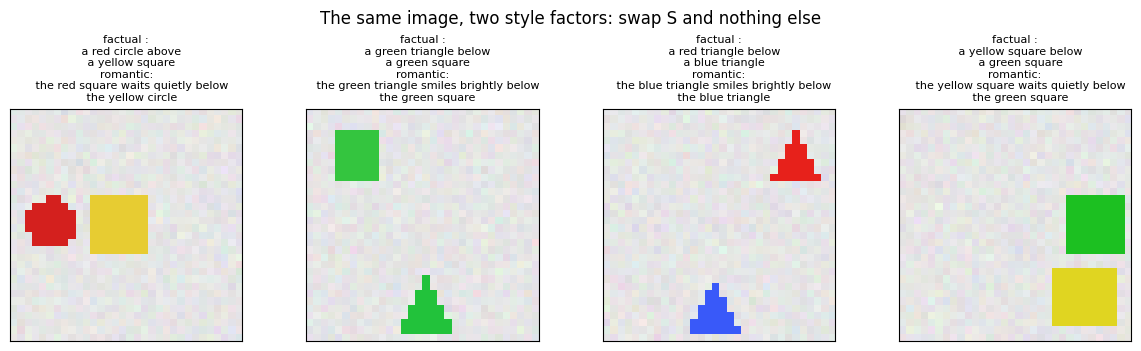

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4))
for ax, i in zip(axes, range(4)):
    show_img(ax, Xte[i], f'factual : {caps_style["factual"][i]}\nromantic: {caps_style["romantic"][i]}'.replace(' a ', '\n   a ').replace(' the ', '\n   the '))
fig.suptitle('The same image, two style factors: swap S and nothing else', y=1.02)
plt.tight_layout(); plt.show()

### Widget 7: interpolate the style factor

Nothing forces $\mathbf{S}$ to be one of the two trained factors. The slider sets $\mathbf{S} = (1 - \lambda)\, \mathbf{S}_{\text{factual}} + \lambda\, \mathbf{S}_{\text{romantic}}$ (captions for every $\lambda$ are precomputed on the test set). The switch is not gradual: the style rate stays at zero up to $\lambda = 0.5$ and jumps to one between $0.5$ and $0.75$, while the content slots decline only slightly across the whole range. Pick a scene and read the five captions to see where its style flips.

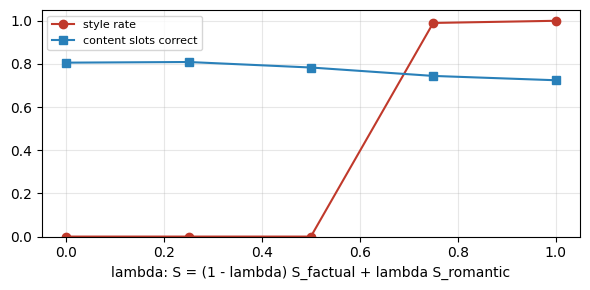

interactive(children=(IntSlider(value=0, continuous_update=False, description='index', max=399), Dropdown(desc…

In [40]:
LAMBDAS = [0.0, 0.25, 0.5, 0.75, 1.0]
caps_mix = {lam: style_captions(stylenet, Fte, mix=lam) for lam in LAMBDAS}
mix_scores = {lam: style_scores(caps_mix[lam], refs_te) for lam in LAMBDAS}

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(LAMBDAS, [mix_scores[l][2] for l in LAMBDAS], 'o-', color='#c0392b', label='style rate')
ax.plot(LAMBDAS, [mix_scores[l][0] for l in LAMBDAS], 's-', color='#2980b9', label='content slots correct')
ax.set_xlabel('lambda: S = (1 - lambda) S_factual + lambda S_romantic'); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

def style_widget(index=0, lam=1.0):
    fig, ax = plt.subplots(figsize=(3.0, 3.0))
    show_img(ax, Xte[index], f'test scene {index}')
    plt.tight_layout(); plt.show()
    print('references:', ' | '.join(refs_te[index]))
    for l in LAMBDAS:
        print(f'{">>" if l == lam else "  "} lambda {l:4.2f}: "{caps_mix[l][index]}"')

interact(style_widget, index=IntSlider(min=0, max=N_TEST - 1, step=1, value=0, continuous_update=False),
         lam=Dropdown(options=LAMBDAS, value=1.0, description='lambda'));

## 8. Neural Baby Talk: templates with grounded slots

*Lu et al., CVPR 2018* close the lecture with a different division of labour. Every captioner so far generates words directly, and a word like "circle" is only loosely tied to a region, through an attention map at best. Neural Baby Talk generates a **template** instead: a sentence with **slots** (the paper's "visual words"), such as *"A `[ ]` above a `[ ]`"*, where each slot is bound to one **detected region** of the image by pointing (an attention over the boxes of an object detector). A second stage then fills each slot from its region: the detector's category, refined by a fine-grained classifier ("kitten" for a "cat" box) and a plurality classifier (singular or plural). Adjectives such as "red" remain textual words of the template, produced by the language model like every other non-slot word.

The name is a tribute to *Baby Talk* (Kulkarni et al., 2011), the pre-deep-learning captioner that stitched detector outputs into a fixed template. Neural Baby Talk keeps the grounding of that approach and lets a network write the template, which is why its captions can name objects the caption training set never contained: the detector, not the language model, decides what is in the box. The figure below draws the idea on one of our scenes, with the ground-truth boxes standing in for a detector and the shape word as the slot's category; in this toy version the colour is a textual word.

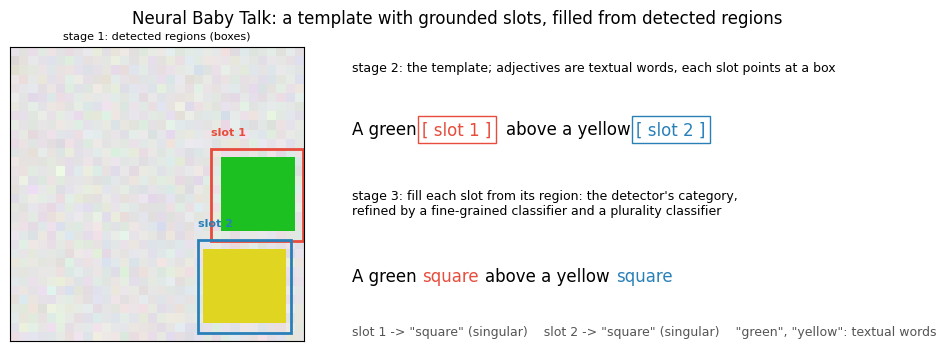

In [41]:
i = 3
obs = objs_te[i]; ref = parse_caption(refs_te[i][0])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw=dict(width_ratios=[1, 1.6]))
show_img(axes[0], Xte[i], 'stage 1: detected regions (boxes)')
slot_colors = ['#e74c3c', '#2980b9']
order = sorted(range(len(obs)), key=lambda k: ((obs[k]['color'], obs[k]['shape']) != ref['subj']))   # subject first
for slot, k in enumerate(order):
    o = obs[k]
    axes[0].add_patch(patches.Rectangle((o['cx'] - o['r'] - 1, o['cy'] - o['r'] - 1), 2 * o['r'] + 2, 2 * o['r'] + 2,
                                        fill=False, edgecolor=slot_colors[slot], lw=2))
    axes[0].text(o['cx'] - o['r'] - 1, o['cy'] - o['r'] - 2.5, f'slot {slot + 1}', color=slot_colors[slot], fontsize=8, fontweight='bold')
ax = axes[1]; ax.axis('off')
plt.tight_layout(); fig.canvas.draw(); renderer = fig.canvas.get_renderer()

def write_pieces(ax, y, pieces, fontsize=12):
    """Write (text, colour, boxed) pieces left to right on one line, measuring each piece so nothing overlaps."""
    x = 0.0
    for text, color, boxed in pieces:
        t = ax.text(x, y, text, fontsize=fontsize, color=color, transform=ax.transAxes, va='center',
                    bbox=dict(fc='white', ec=color, pad=3) if boxed else None)
        x = ax.transAxes.inverted().transform((t.get_window_extent(renderer).x1 + (14 if boxed else 6), 0))[0]

(c1, s1), rel, (c2, s2) = ref['subj'], ref['rel'], ref['obj']
ax.text(0.0, 0.92, 'stage 2: the template; adjectives are textual words, each slot points at a box', fontsize=9, transform=ax.transAxes)
write_pieces(ax, 0.72, [(f'A {c1}', 'black', False), ('[ slot 1 ]', slot_colors[0], True), (f'{rel} a {c2}', 'black', False), ('[ slot 2 ]', slot_colors[1], True)])
ax.text(0.0, 0.47, "stage 3: fill each slot from its region: the detector's category,\nrefined by a fine-grained classifier and a plurality classifier", fontsize=9, transform=ax.transAxes, va='center')
write_pieces(ax, 0.22, [(f'A {c1}', 'black', False), (s1, slot_colors[0], False), (f'{rel} a {c2}', 'black', False), (s2, slot_colors[1], False)])
ax.text(0.0, 0.02, f'slot 1 -> "{s1}" (singular)    slot 2 -> "{s2}" (singular)    "{c1}", "{c2}": textual words', fontsize=9, transform=ax.transAxes, color='#555555')
fig.suptitle('Neural Baby Talk: a template with grounded slots, filled from detected regions', y=1.02)
plt.show()

## 9. The slide's homework, answered: caption to image

The lecture ends with a question: *"Can we do the opposite (caption-to-image) of what we learnt in this section? How?"* The next lecture's review answers it in one line, *"Yes, we will see deep generative models soon that can do this"*, and our dataset shows why a generative model is needed rather than a simple inversion of the captioner.

**A caption is a many-to-one function of the image.** The first cell collects every training scene whose target caption is one particular sentence. They differ in the objects' exact positions, sizes and colour jitter, and there are dozens of them. Inverting the caption therefore means choosing among many valid images, which is what sampling from $p(\text{image} \mid \text{caption})$ does, and what the diffusion models of later weeks are built for.

**What the captioner can do without a generator is search.** Any model that scores $p(\text{caption} \mid \text{image})$ can rank a *set* of images by how well they fit a caption; the second cell uses the Show and Tell model of Section 1 as a retrieval engine over the 400 test images and reports how often the true scene is ranked first. That is text-to-image *retrieval*, a genuinely useful inverse, but it can only return images that already exist.

527 distinct target captions among 6000 training scenes; "a green circle above a green square" is the target of 30 different images


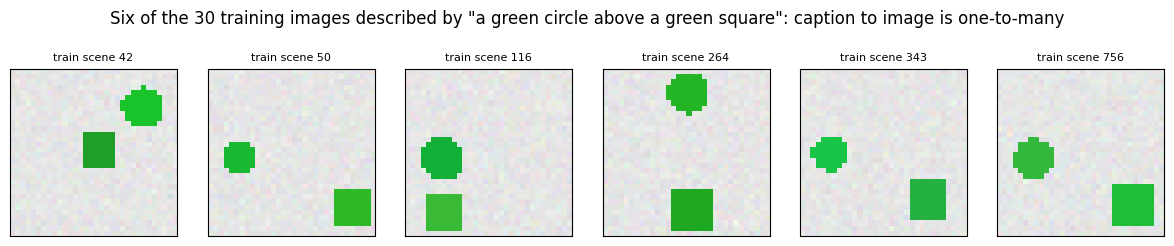

In [42]:
by_caption = {}
for k, c in enumerate(caps_tr):
    by_caption.setdefault(c, []).append(k)
cap_star, members = max(by_caption.items(), key=lambda kv: len(kv[1]))
print(f'{len(by_caption)} distinct target captions among {N_TRAIN} training scenes; '
      f'"{cap_star}" is the target of {len(members)} different images')

fig, axes = plt.subplots(1, 6, figsize=(12, 2.3))
for ax, k in zip(axes, members[:6]):
    show_img(ax, Xtr[k], f'train scene {k}')
fig.suptitle(f'Six of the {len(members)} training images described by "{cap_star}": caption to image is one-to-many', y=1.05)
plt.tight_layout(); plt.show()

text-to-image retrieval with the captioner as scorer, 100 query captions over 400 test images:
  recall@1 0.70 | recall@5 0.99 | median rank 1 (chance: recall@1 0.0025, median rank 200)


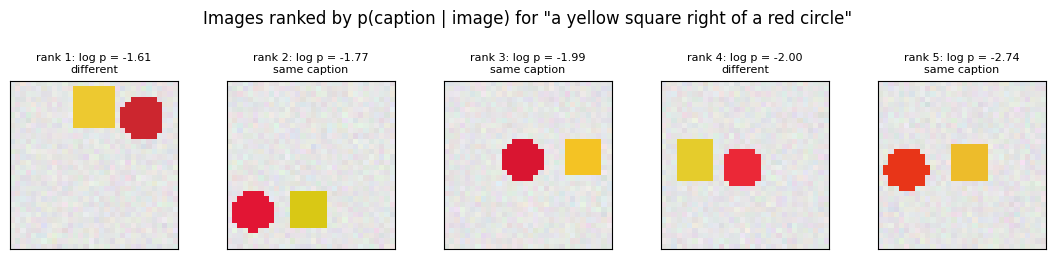

In [43]:
@torch.no_grad()
def caption_logprob(model, f, Y):
    """log p(caption Y | image f) under teacher forcing, summed over the words. f: (N, L, D), Y: (N, T)."""
    logp = F.log_softmax(model(f, Y), -1)
    tgt = Y[:, 1:]; mask = (tgt != PAD).float()
    return (logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1) * mask).sum(1)

n_query = 100
ranks = []
for q in range(n_query):
    scores = caption_logprob(show_tell, Fte, Yte[q:q + 1].expand(N_TEST, -1))       # score every test image for caption q
    order = scores.argsort(descending=True)
    # the query caption may describe other test scenes too (as their target or their other reference): any of them is a hit
    hits = torch.tensor([caps_te[q] in refs_te[j] for j in range(N_TEST)], device=device)
    ranks.append(int(hits[order].nonzero()[0].item()) + 1)
ranks = np.array(ranks)
print(f'text-to-image retrieval with the captioner as scorer, {n_query} query captions over {N_TEST} test images:')
print(f'  recall@1 {np.mean(ranks == 1):.2f} | recall@5 {np.mean(ranks <= 5):.2f} | median rank {np.median(ranks):.0f} '
      f'(chance: recall@1 {1 / N_TEST:.4f}, median rank {N_TEST // 2})')

q = 0
scores = caption_logprob(show_tell, Fte, Yte[q:q + 1].expand(N_TEST, -1)); top = scores.argsort(descending=True)[:5].tolist()
fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
for ax, j in zip(axes, top):
    show_img(ax, Xte[j], f'rank {top.index(j) + 1}: log p = {scores[j]:.2f}\n{"same caption" if caps_te[q] in refs_te[j] else "different"}')
fig.suptitle(f'Images ranked by p(caption | image) for "{caps_te[q]}"', y=1.06)
plt.tight_layout(); plt.show()

## 10. Explore and verify

The notebook has checked its from-scratch components against references as it went: the ReLU RNN step against `nn.RNNCell` and `nn.RNN`, beam search against greedy decoding and against exhaustive search, BLEU against the paper's hand-worked values, the attention step against `F.scaled_dot_product_attention`, the REINFORCE estimate against the exact gradient, and the factored cell against `nn.LSTMCell`. The cell below re-runs the ones that hold exactly, in one place, and adds the properties of the attention weights themselves: that the context vector is a convex combination of the annotations, and what uniform and one-hot weights reduce to.

In [44]:
# The checks that hold exactly, re-run in one place.
_g = greedy_decode(show_tell, show_tell.init_state(Fte[:64]))
assert torch.equal(_g, beam_search(show_tell, show_tell.init_state(Fte[:64]), k=1)[0][:, 0])
assert np.allclose(bleu(caps_te[:20], [[c] for c in caps_te[:20]]), [1, 1, 1, 1])
_z, _a = attend_scratch(_q, _k, _v)
assert torch.allclose(_z, F.scaled_dot_product_attention(_q.unsqueeze(1), _k, _v).squeeze(1), atol=1e-5)
assert torch.allclose(_fc(_x, (_h0, _c0))[0], _ref(_x, (_h0, _c0))[0], atol=1e-5)
assert (M_soft.sum(-1) - 1).abs().max() < 1e-5 and (M_hard.sum(-1) - 1).abs().max() < 1e-5
print('beam search k=1 == greedy            ok')
print('BLEU of a caption against itself == 1  ok')
print('attention step == SDPA                 ok')
print('factored LSTM cell == nn.LSTMCell      ok')
print('every learned attention map sums to 1  ok')

beam search k=1 == greedy            ok
BLEU of a caption against itself == 1  ok
attention step == SDPA                 ok
factored LSTM cell == nn.LSTMCell      ok
every learned attention map sums to 1  ok


In [45]:
# Verify the properties of the captioning attention.

# 1. The context vector is a convex combination, so it lies inside the convex hull.
a_test = torch.softmax(torch.randn(L), dim=0)
z_test = a_test @ V_ann
lo, hi = V_ann.min(0).values, V_ann.max(0).values
assert (z_test >= lo - 1e-4).all() and (z_test <= hi + 1e-4).all(), 'context escaped the hull'

# 2. Uniform attention gives exactly the mean annotation - the no-attention baseline.
uniform = torch.full((L,), 1.0 / L)
assert torch.allclose(uniform @ V_ann, V_ann.mean(0), atol=1e-5)

# 3. A one-hot (hard) attention returns exactly one annotation vector, unchanged.
onehot = torch.zeros(L); onehot[42] = 1.0
assert torch.allclose(onehot @ V_ann, V_ann[42], atol=1e-6)

print(f'  context vector lies within the annotation hull        ok')
print(f'  uniform attention == mean annotation (no attention)   ok')
print(f'  one-hot attention == a single annotation, unchanged   ok')
print(f'\n  so attention interpolates between "look everywhere" and "look at one patch";')
print(f'  entropy of uniform over L={L} is log(L) = {np.log(L):.3f} nats')

  context vector lies within the annotation hull        ok
  uniform attention == mean annotation (no attention)   ok
  one-hot attention == a single annotation, unchanged   ok

  so attention interpolates between "look everywhere" and "look at one patch";
  entropy of uniform over L=196 is log(L) = 5.278 nats


A static sweep over the sharpness of a random attention map on the slide's $14 \times 14$ grid, from uniform to nearly one-hot: the entropy falls from $\log 196$ towards zero as the map concentrates.

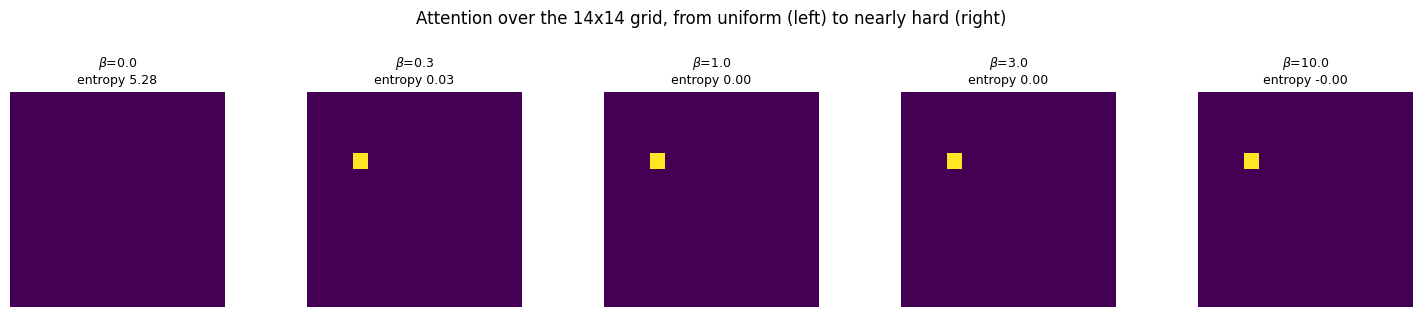

In [46]:
# Static sweep: attention entropy from fully peaked to fully uniform, on a 14x14 grid.
fig, ax = plt.subplots(1, 5, figsize=(15, 3.0))
base = (V_ann @ torch.randn(D_ann))
for a_, beta in zip(ax, [0.0, 0.3, 1.0, 3.0, 10.0]):
    w = torch.softmax(beta * base, dim=0)
    ent = -(w * (w + 1e-12).log()).sum()
    a_.imshow(w.reshape(W_grid, H_grid), cmap='viridis')
    a_.set_axis_off()
    a_.set_title(f'$\\beta$={beta}\nentropy {ent:.2f}', fontsize=9)
fig.suptitle('Attention over the 14x14 grid, from uniform (left) to nearly hard (right)', y=1.04)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [47]:
# Live: sharpen the attention map and watch the context vector move.
from ipywidgets import interact, FloatSlider

def attend(beta=1.0):
    w = torch.softmax(beta * base, dim=0)
    z_ = w @ V_ann
    ent = -(w * (w + 1e-12).log()).sum()
    dist_to_mean = (z_ - V_ann.mean(0)).norm()
    fig, ax_ = plt.subplots(1, 2, figsize=(9, 3.4))
    ax_[0].imshow(w.reshape(W_grid, H_grid), cmap='viridis'); ax_[0].set_axis_off()
    ax_[0].set_title(f'attention map, entropy {ent:.2f} nats')
    ax_[1].bar(range(40), z_[:40].numpy(), color='steelblue')
    ax_[1].set_title(f'context vector (first 40 dims)\ndistance from mean annotation {dist_to_mean:.2f}')
    plt.tight_layout(); plt.show()

interact(attend, beta=FloatSlider(min=0.0, max=10.0, step=0.25, value=1.0));

interactive(children=(FloatSlider(value=1.0, description='beta', max=10.0, step=0.25), Output()), _dom_classes…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Show and Tell** | A pretrained CNN's penultimate vector $v$ enters a recurrent language model once, $h_0 = \max(0, W_{xh} x_0 + W_{ih} v)$; training is teacher forcing with a cross-entropy on the next word |
| **Keeping the image alive** | A once-injected image only helps if the recurrence preserves it: an identity-initialised ReLU RNN did, an LSTM with a $\tanh$-squashed initial state forgot it: the gradient into the image path collapsed and, on the same budget, the model reached about 17% exact match against the ReLU RNN's 56% |
| **Decoding** | Greedy picks the argmax word; beam search keeps $k$ partial captions and maximises log-probability, which is not the same as correctness; sampling with a temperature trades correctness for diversity |
| **BLEU** | Clipped $n$-gram precision times a brevity penalty; BLEU-1 is nearly free, BLEU-4 rewards word order; always compare with a trivial baseline |
| **Attention** | $L = W \times H$ annotations of width $D$; $z_t = \sum_i \alpha_{t,i} v_i$ is a convex combination, verified against `scaled_dot_product_attention`; the map per word makes failures explainable, but the annotations must carry their position or the weighted average loses the relation between objects |
| **Soft vs hard** | Hard attention is an unbiased estimator of soft attention but has no gradient; REINFORCE, $\mathbb{E}[f(s) \nabla \log p(s)]$, trains it, but even with a running baseline, a normalised advantage and half-soft mixing it trails soft attention by a wide margin on our budget (0.33 against 0.59 exact match) |
| **LSTM-A** | Five injection schedules; in our small setting per-step image injection (A4) wins because it sidesteps the fragile once-injected path, and under test-time image noise A4 loses more exact match than A3 in absolute terms, but relative to what the image contributes only when the same corruption is repeated at every step: consistent with the slide's accumulation mechanism, not a clean confirmation of it |
| **StyleNet** | $W_x = U_x S_x V_x$; train $U, V$ on paired factual data, $S_{\text{style}}$ on unpaired text, swap or even interpolate $S$ at test time; style transfers fully, content only partially |
| **Neural Baby Talk** | Generate a template with slots grounded in detected regions, then fill the slots from the regions |
| **Caption to image** | One-to-many, so it needs a generative model; a captioner can already rank existing images by $p(\text{caption} \mid \text{image})$ |

**Methods at a glance**

| | Show and Tell | Show, Attend and Tell (soft) | Hard attention | LSTM-A | StyleNet | Neural Baby Talk |
|---|---|---|---|---|---|---|
| **Image enters** | once, as $h_0$ or first input | every step, via $z_t$ | every step, one sampled $v_i$ | schedule A1 to A5 | once, factual stage only | via detected regions |
| **Extra input** | none | none | none | attributes $\mathbf{A}$ | unpaired styled text | object detector |
| **Training** | cross-entropy | cross-entropy | cross-entropy + REINFORCE | cross-entropy | alternating paired / unpaired | template + slot losses |
| **Explains itself?** | no | attention map per word | one location per word | no | no | slot pointing at a box |

## Exercises

1. **The homework from the slides.** Can we do the opposite, caption to image? Section 9 showed that dozens of training images share one caption. Write down what a model of $p(\text{image} \mid \text{caption})$ must represent that the retrieval engine does not, and say which component of the captioning pipeline has no obvious inverse. Then read the review slide of the next lecture: which family of models is the answer?

2. **Three objects.** Set `MAX_OBJ = 3` in Section 0, rerun the notebook, and report exact match and BLEU-4 for Show and Tell and for soft attention. `make_scene` draws two or three objects per scene, so explain why three-object scenes now have six references (every ordered pair of the three objects) while two-object scenes keep two, and why the exact-match ceiling for a model that never learns to choose a pair is much lower. *(We measured Show and Tell falling from about 0.55 to about 0.25 exact match with the same budget.)*

3. **Beam width versus BLEU.** Extend `BEAMS` to include 12 and 20 and add BLEU-4 to the beam-width figure. Does the wider beam keep raising the log-probability? Does BLEU follow it? Relate the answer to the fact that beam search maximises the wrong quantity.

4. **A4 versus A3 with a noisier detector.** Section 6.3 added noise at test time. Add it during *training* instead (set `noise` before training and keep it during decoding) and retrain A3 and A4 for the same 8 epochs. Report whether the gap between them widens, which is what the slide's overfitting explanation predicts.

5. **The missing tanh.** The StyleNet slide prints $h_t = o_t \odot c_t$ while its figure shows a $\tanh$. Copy `FactoredLSTMCell`, remove the $\tanh$ from the output line, run both cells for 50 steps on random inputs from the same state, and show which one keeps the hidden state bounded.

6. **How many samples for hard attention?** Section 5.1 measured the variance of the score-function estimator with and without a baseline. Repeat the measurement for `n_samp` in 10, 100, 1000, 10000 and plot the relative error of the estimate against the number of samples on log axes. What slope do you expect, and how many samples would a 1% error need with and without the baseline?